# Image Classification End-to-End: From Scratch → Transfer Learning 

## What this notebook covers

Four things, in order:

1. **Binary classification with a CNN built from scratch** — the implementation defines every layer directly and shows how `Conv2d`, `ReLU`, `MaxPool`, `Flatten`, and `Linear` transform image tensors.
2. **Multi-class classification with the same CNN** — the workflow shows that moving from 2 classes to 10 is a one-line code change (output dimension + loss function).
3. **Transfer learning — feature extraction mode** — take a pretrained ResNet, freeze the backbone, train only a new head. This is the fastest and most common starting point in industry.
4. **Transfer learning — fine-tuning mode** — selectively unfreeze layers, use different learning rates for different parts of the network, and apply every production-grade trick (discriminative LRs, LR schedules, label smoothing, mixed precision, early stopping, class weighting).

By the end, the workflow establishes the standard choices for a classification task:
- When to build from scratch vs. use transfer learning (almost always transfer learning)
- What to freeze, what to unfreeze, and when to flip between them
- How to pick learning rates for each layer group
- How to handle class imbalance cleanly
- How to structure a reproducible training run

## Dataset: EuroSAT (satellite land-cover classification)

- **10 classes** of European land cover: AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, Pasture, PermanentCrop, Residential, River, SeaLake.
- **27,000 RGB images, 64×64 pixels**. About ~100 MB zipped.
- **Downloads automatically** via `torchvision.datasets.EuroSAT(download=True)` — no API keys, no Kaggle auth, no Roboflow account.
- **MIT licensed.**
- **Real industrial application**: land-cover classification from satellite imagery is used in agriculture monitoring, urban planning, deforestation detection, climate research.

## Prerequisites

Key points:
- PyTorch basics (tensors, `nn.Module`, autograd)
- What a CNN is at a conceptual level (convolutions, pooling)
- What softmax, cross-entropy, and backpropagation do
- What transfer learning means at the "I've heard of it" level

If you have the `YOLO_Practical_Guide.md` companion doc, Section 0 ("From What You Already Know to YOLO") covers the classification foundations we build on here.

## Hardware

- **Colab free T4 GPU**: full notebook runs in ~20 min.
- **Local NVIDIA GPU**: similar.
- **CPU only**: works (we auto-scale down image size and epochs), ~1 hour.


### Reading Guide

This copy keeps the executable code unchanged and adds concise notes around the main decisions. Focus on four recurring ideas: data preparation, tensor shape, loss function choice, and which parameters are safe to change during experimentation.

**Notation used throughout**
- `B`: batch size
- `C`: number of channels or classes, depending on context
- `H x W`: image height and width
- `logits`: raw model outputs before sigmoid or softmax


---
## Section 1: Environment Setup

Everything we need is already in any standard PyTorch install. No exotic packages.


In [ ]:
# Standard PyTorch + torchvision + the usual DS stack.
# On Colab, these are usually pre-installed.
# For a local setup, install with `pip install torch torchvision matplotlib scikit-learn tqdm`.

import os
import random
import time
import copy
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler, random_split
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights, ResNet50_Weights

from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_fscore_support
)

# --- Reproducibility ---
# We set every seed we can. CUDA operations are still not 100% deterministic
# (cuDNN algorithms vary), but this gets us ~95% reproducible runs.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Hardware check ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device:          {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
    print(f"Memory:          {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU detected. We'll scale down the workload to keep training tractable on CPU.")


PyTorch version: 2.10.0+cu128
Device:          cuda
GPU:             Tesla T4
Memory:          15.6 GB


---
## Section 2: Download and Explore EuroSAT

`torchvision.datasets.EuroSAT(root, download=True)` fetches a ~100 MB zip from a public mirror and unpacks it into an `ImageFolder`-style structure. Zero configuration needed.

### Dataset structure used here

```
./data/eurosat/2750/
    AnnualCrop/        (3000 images)
    Forest/            (3000 images)
    HerbaceousVegetation/ (3000 images)
    Highway/           (2500 images)
    Industrial/        (2500 images)
    Pasture/           (2000 images)
    PermanentCrop/     (2500 images)
    Residential/       (3000 images)
    River/             (2500 images)
    SeaLake/           (3000 images)
```

Note the mild class imbalance (some have 2000, some have 3000). The workflow addresses this in the training code. This is realistic — perfectly balanced datasets are uncommon in the real world.


### Notes: Dataset Choice

EuroSAT is useful because it is small enough for quick experiments but still realistic. It contains visually easy classes, visually similar classes, and mild class imbalance.

**Alternative datasets**
- `torchvision.datasets.CIFAR10`: smaller natural-image classification, good for debugging CNN code.
- `torchvision.datasets.ImageFolder`: use this when images are already arranged as `class_name/image.jpg` folders.
- Custom `Dataset`: use this when labels come from a CSV, database, or annotation file.

**Parameter alternatives**
- `root='./data'`: can be changed to any dataset storage path.
- `download=True`: use once when internet is available; later runs can use `download=False`.
- `transform=None`: useful for raw exploration; later cells attach transforms per split.


In [ ]:
DATA_ROOT = Path('./data')
DATA_ROOT.mkdir(exist_ok=True)

# The first call downloads ~100 MB. Subsequent calls skip the download.
# We pass transform=None because we'll first explore the raw PIL images before
# writing our transform pipeline.
print("Downloading EuroSAT (first time only, ~100 MB)...")
full_dataset_raw = datasets.EuroSAT(root=str(DATA_ROOT), download=True, transform=None)
print(f"Done. Dataset size: {len(full_dataset_raw)} images")
print(f"Number of classes: {len(full_dataset_raw.classes)}")
print(f"Classes: {full_dataset_raw.classes}")


100%|██████████| 94.3M/94.3M [00:00<00:00, 379MB/s]


Done. Dataset size: 27000 images
Number of classes: 10
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


          class_name  count   pct
          AnnualCrop   3000 11.11
              Forest   3000 11.11
HerbaceousVegetation   3000 11.11
             Highway   2500  9.26
          Industrial   2500  9.26
             Pasture   2000  7.41
       PermanentCrop   2500  9.26
         Residential   3000 11.11
               River   2500  9.26
             SeaLake   3000 11.11


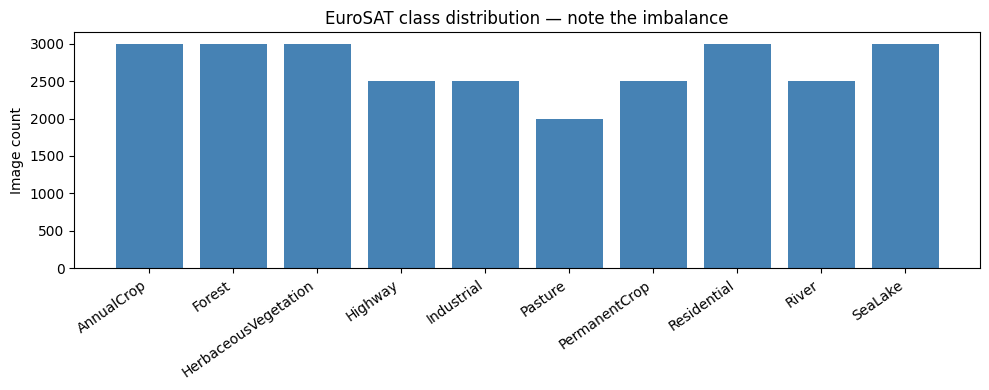

In [ ]:
# Count how many images per class. Real-world: ALWAYS check this before training.
class_counts = Counter([label for _, label in full_dataset_raw.samples])
class_names = full_dataset_raw.classes

dist_df = pd.DataFrame({
    'class_name': [class_names[i] for i in sorted(class_counts)],
    'count':      [class_counts[i] for i in sorted(class_counts)],
})
dist_df['pct'] = (dist_df['count'] / dist_df['count'].sum() * 100).round(2)
print(dist_df.to_string(index=False))

# Plot the distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(dist_df['class_name'], dist_df['count'], color='steelblue')
ax.set_title('EuroSAT class distribution — note the imbalance')
ax.set_ylabel('Image count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

# The smallest class (Pasture, 2000) is 33% smaller than the largest (AnnualCrop,
# 3000). Not catastrophic, but enough that we should watch per-class recall and
# consider class-weighted loss. We'll do both.


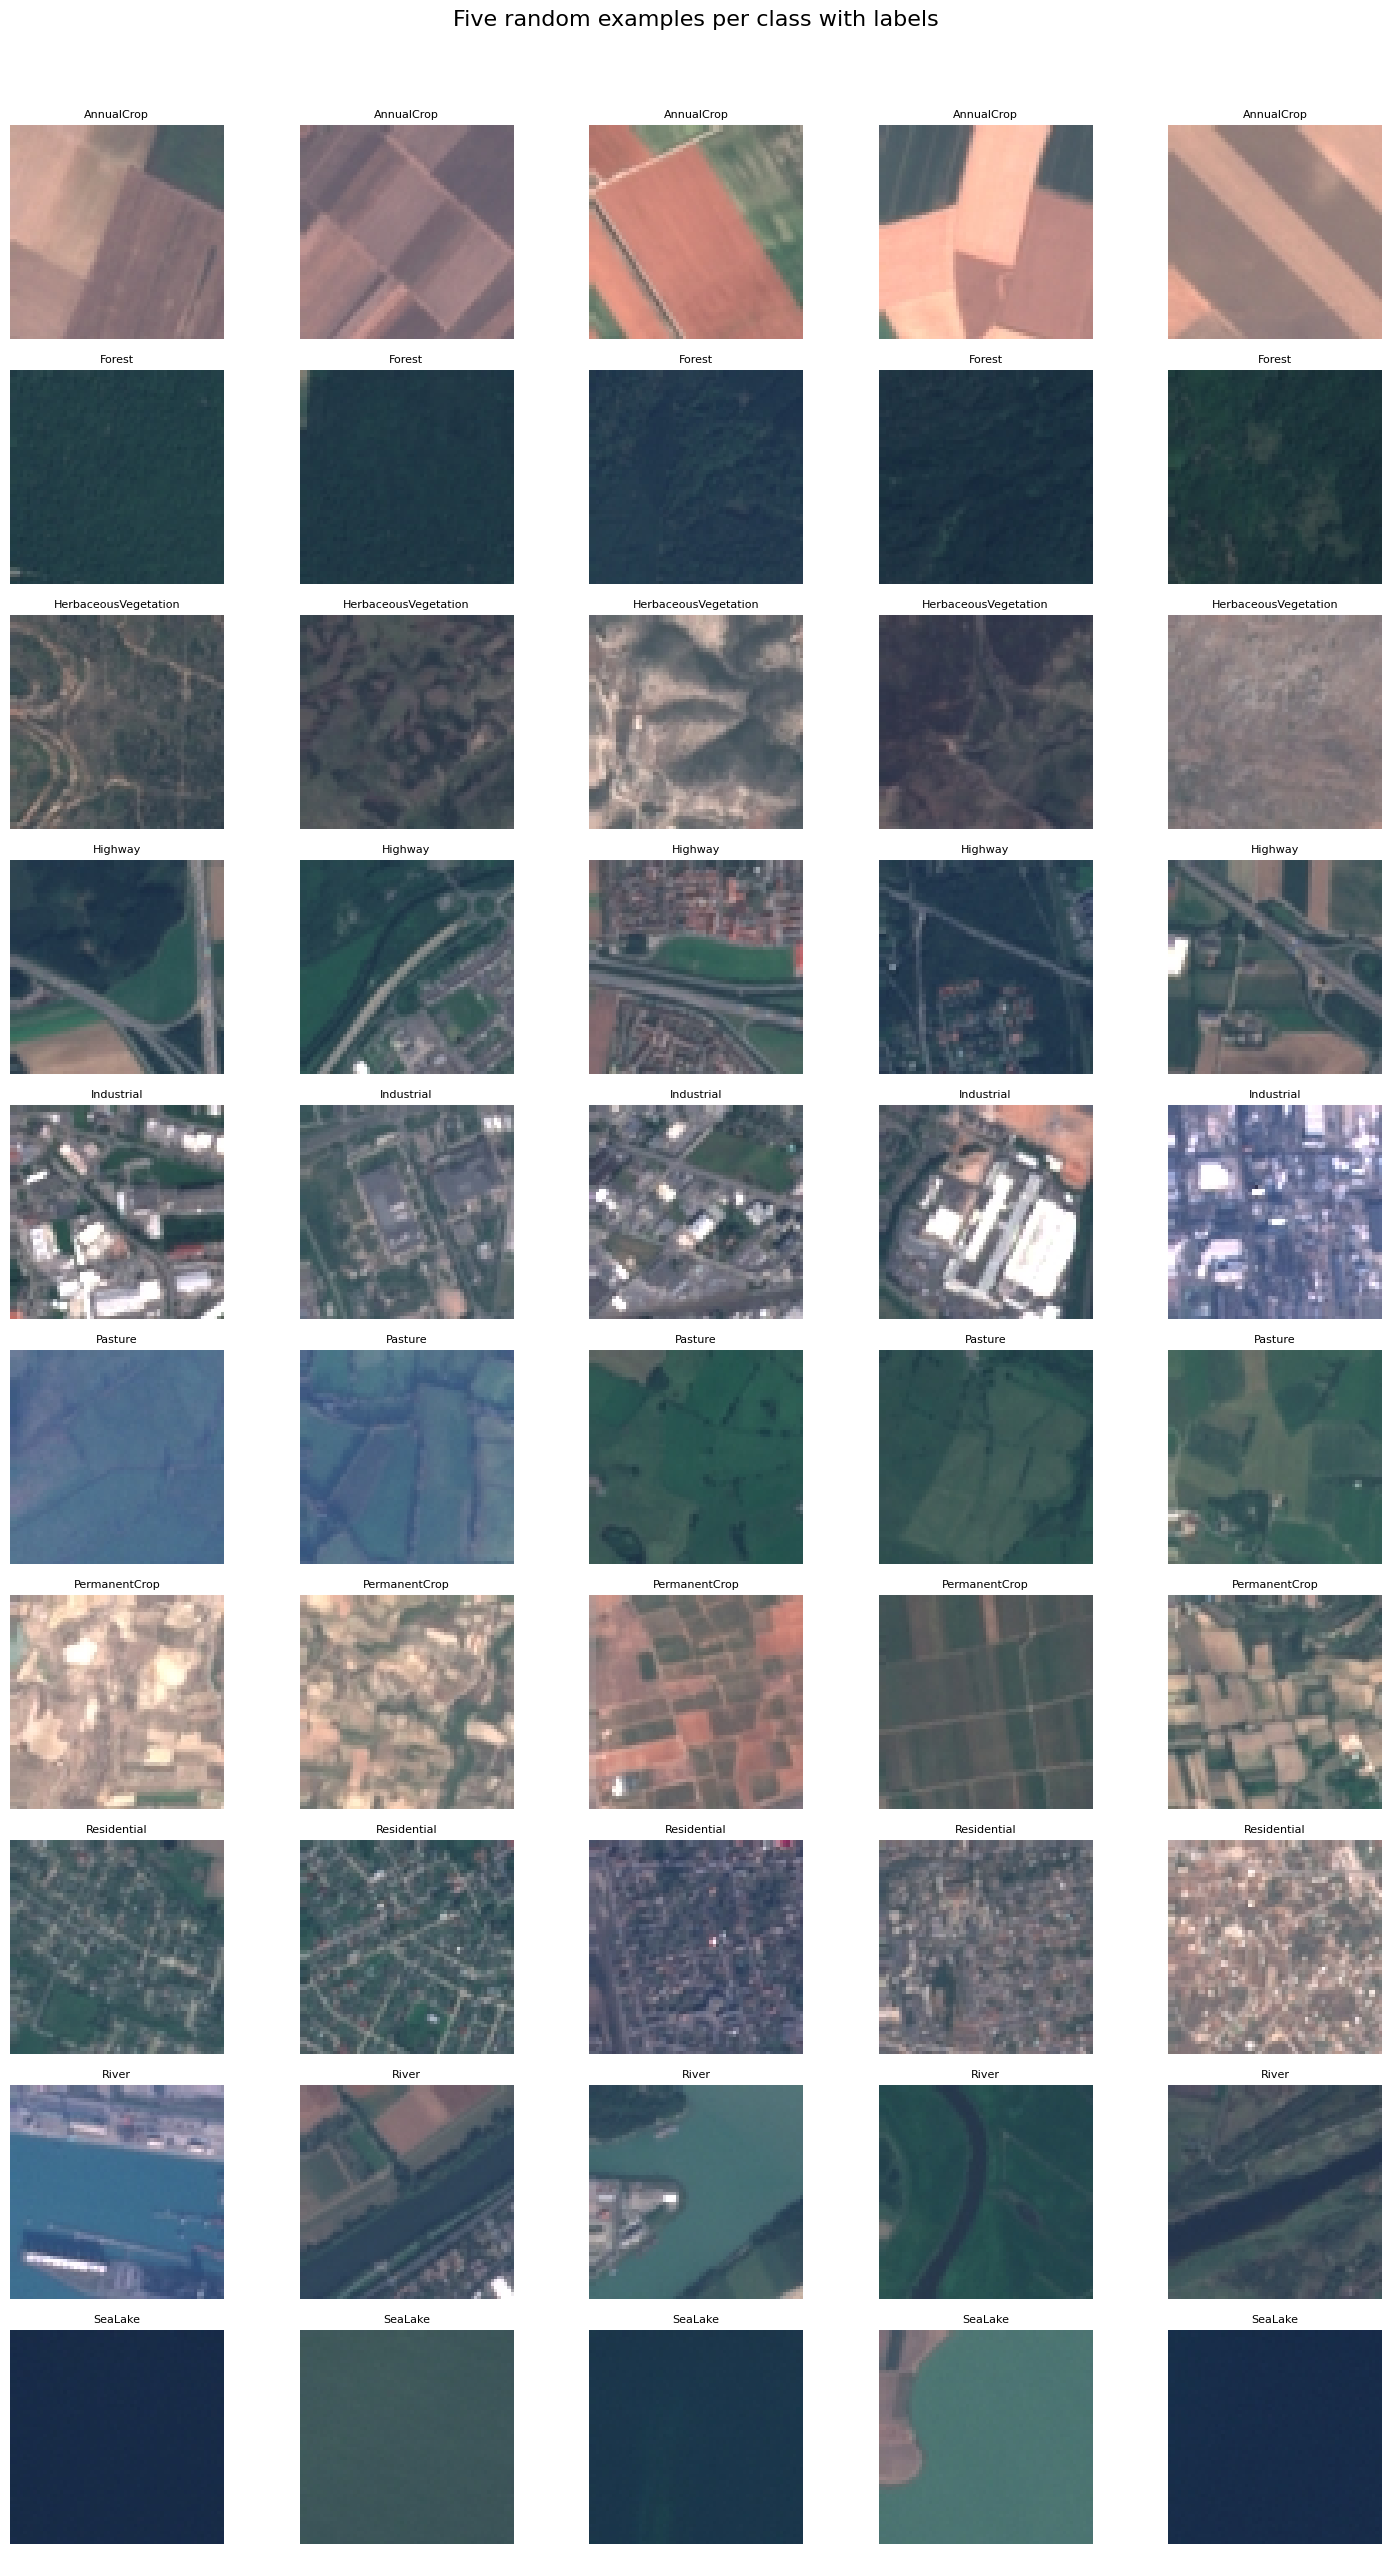

In [ ]:
from PIL import Image

# Initialize a grid of 10 rows (one per class) and 5 columns (examples per class)
fig, axes = plt.subplots(10, 5, figsize=(15, 25))

for class_idx, class_name in enumerate(class_names):
    # Filter dataset indices to find all images belonging to the current class
    indices = [i for i, (_, lbl) in enumerate(full_dataset_raw.samples) if lbl == class_idx]

    # Randomly select 5 unique image indices for this class
    chosen = random.sample(indices, 5)

    for col, idx in enumerate(chosen):
        # Load the image and convert it to RGB
        img_path, _ = full_dataset_raw.samples[idx]
        img = Image.open(img_path).convert('RGB')

        # Display image in the corresponding subplot
        axes[class_idx, col].imshow(img)

        # Add the class name as a title for each individual image
        axes[class_idx, col].set_title(class_name, fontsize=8)

        # Hide x and y axis ticks for a cleaner visual representation
        axes[class_idx, col].axis('off')

        # Add a vertical row label on the left-most column for easier navigation
        if col == 0:
            axes[class_idx, col].set_ylabel(class_name, fontsize=10, rotation=0,
                                             labelpad=60, ha='right', va='center')

# Set a global title for the entire figure
plt.suptitle('Five random examples per class with labels', fontsize=16, y=1.02)

# Adjust spacing automatically to prevent label overlapping
plt.tight_layout()
plt.show()

**Observations:**
- `Forest` vs `Residential` are *visually extremely different* — a simple model should crush this (we'll use this pair for binary classification).
- `River` vs `SeaLake` look similar (both are water). Hard class pair.
- `AnnualCrop` vs `Pasture` vs `PermanentCrop` vs `HerbaceousVegetation` — four green-ish textures. Confusing. This is where real modeling effort pays off.
- All images are 64×64 RGB. Small enough for a CNN from scratch, big enough that transfer learning is still helpful.


---
## Section 3: Building the Data Pipeline

Now we set up the train/val/test split and the data-loading pipeline. Industry standard is:

- **Train set (70%)**: the model's learning material.
- **Val set (15%)**: used during training for hyperparameter tuning, early stopping, learning rate scheduling. **You tune on this.**
- **Test set (15%)**: **used ONCE at the end** to report final numbers. Never tune on it — if you do, you've leaked test info into your modelling decisions, and your reported test metrics are optimistic.

### Important detail: stratified split

Random splitting can accidentally under-represent rare classes in val/test. **Always stratify** — ensure each split has the same class proportions as the overall data.

### Transforms — two different pipelines for train vs val/test

- **Training transforms**: include data augmentation (random crops, flips, color jitter). Augmentation is a regularizer — it prevents the model from memorizing specific pixel patterns.
- **Val/test transforms**: no augmentation, no randomness. Just deterministic resize and normalize. Validation must be reproducible to be meaningful.

### Normalization constants

Using ImageNet's mean and std (`[0.485, 0.456, 0.406]` / `[0.229, 0.224, 0.225]`). This is standard practice when you'll use ImageNet-pretrained models — the preprocessing must match what the backbone was trained with. For from-scratch models, the choice is less critical, but using the same constants makes comparisons cleaner.


### Notes: Data Pipeline Decisions

The split and transform pipeline control the quality of the experiment as much as the model does.

**Common alternatives**
- Split ratio: `70/15/15` is a strong default. For very small datasets, use `80/10/10` or cross-validation.
- Resize size: `64` is enough for the scratch CNN because EuroSAT images are natively `64x64`. Larger values increase compute.
- Augmentation: flips and rotations are appropriate for satellite images. For normal photos, vertical flips may be harmful.
- Normalization: ImageNet mean/std is useful for pretrained models. For from-scratch training, dataset-specific mean/std is also valid.

**Common pitfall**
Never apply random augmentation to validation or test data. Metrics become noisy and difficult to compare.


In [ ]:
# Native EuroSAT resolution is 64x64.
IMG_SIZE = 64

# --- Train-time transforms (Used during training to improve generalization) ---
train_tf_scratch = transforms.Compose([
    # 1. Resize images to a consistent 64x64. Models require uniform input shapes.
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # 2. 50% chance to flip horizontally. In satellite imagery, the orientation
    # of a field or forest is arbitrary, so this doubles our dataset variety.
    transforms.RandomHorizontalFlip(p=0.5),

    # 3. 50% chance to flip vertically. Unlike photos of cats/cars,
    # satellite views have no fixed 'up' or 'down'.
    transforms.RandomVerticalFlip(p=0.5),

    # 4. Small rotation to help the model recognize features at different angles.
    transforms.RandomRotation(degrees=15),

    # 5. Slightly adjust brightness/contrast to simulate different lighting/weather conditions.
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),

    # 6. Convert PIL image (0-255) to a PyTorch tensor (0-1). Required for neural nets.
    transforms.ToTensor(),

    # 7. Normalize pixel values based on ImageNet stats. This helps the
    # optimizer converge faster by centering the data around zero.
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Eval-time transforms (Used for Validation/Testing) ---
eval_tf_scratch = transforms.Compose([
    # No randomness here! We want our evaluation to be consistent and reproducible.
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print(f"Transforms defined for image size: {IMG_SIZE}x{IMG_SIZE}")

Transforms defined for image size: 64x64


In [ ]:
# --- Stratified train/val/test split ---
# Goal: Split dataset into train/val/test while keeping SAME class distribution
# Strategy:
# 1. Group indices by class
# 2. Split each class separately
# 3. Combine results

def stratified_split(dataset, train_frac=0.7, val_frac=0.15, seed=SEED):
    """
    Returns:
        train_idx, val_idx, test_idx
    Each list contains indices of samples such that
    class distribution is preserved across splits
    """

    # Create reproducible random generator (important for consistent experiments)
    rng = np.random.default_rng(seed)

    # -------------------------------------------------------
    # STEP 1: Group dataset indices by class label
    # -------------------------------------------------------
    # dataset.samples = [(img_path, label), ...]
    # We extract index + label and group indices per class

    class_to_indices = {}

    for idx, (_, label) in enumerate(dataset.samples):
        # If label not present → create empty list
        # Then append index to that class list
        class_to_indices.setdefault(label, []).append(idx)

    # Example structure:
    # {
    #   0: [0, 5, 10, 23, ...],
    #   1: [1, 7, 12, 30, ...],
    #   ...
    # }

    # Prepare final index lists for each split
    train_idx, val_idx, test_idx = [], [], []

    # -------------------------------------------------------
    # STEP 2: Process each class independently
    # -------------------------------------------------------
    for cls, indices in class_to_indices.items():

        # Convert to numpy array for easy slicing
        indices = np.array(indices)

        # Shuffle indices within this class (important to avoid ordering bias)
        rng.shuffle(indices)

        # Total samples in this class
        n = len(indices)

        # Compute split sizes
        n_train = int(n * train_frac)
        n_val   = int(n * val_frac)
        # Remaining automatically goes to test

        # -------------------------------------------------------
        # STEP 3: Split this class into train/val/test
        # -------------------------------------------------------

        # First portion → Train
        train_idx.extend(indices[:n_train].tolist())

        # Next portion → Validation
        val_idx.extend(indices[n_train:n_train + n_val].tolist())

        # Remaining → Test
        test_idx.extend(indices[n_train + n_val:].tolist())

        # 👉 Key idea:
        # Each class contributes proportionally to all splits

    # Return combined indices from all classes
    return train_idx, val_idx, test_idx


# -------------------------------------------------------
# EXECUTE THE SPLIT
# -------------------------------------------------------
train_idx, val_idx, test_idx = stratified_split(full_dataset_raw)

# Print number of samples in each split
print(f"Train: {len(train_idx)} images")
print(f"Val:   {len(val_idx)} images")
print(f"Test:  {len(test_idx)} images")


# -------------------------------------------------------
# VERIFICATION: Check class distribution
# -------------------------------------------------------

def split_class_pct(indices, name):
    """
    Calculate % of each class in a given split
    Helps verify stratification worked correctly
    """

    # Get labels for given indices
    labels = [full_dataset_raw.samples[i][1] for i in indices]

    # Count occurrences of each class
    c = Counter(labels)

    total = len(labels)

    # Convert counts → percentage
    return {
        class_names[k]: round(v / total * 100, 1)
        for k, v in sorted(c.items())
    }


# Create a comparison table across full/train/val/test
split_df = pd.DataFrame({

    # Full dataset distribution (baseline)
    'full': {
        class_names[k]: round(v / len(full_dataset_raw) * 100, 1)
        for k, v in sorted(class_counts.items())
    },

    # Train distribution
    'train': split_class_pct(train_idx, 'train'),

    # Validation distribution
    'val': split_class_pct(val_idx, 'val'),

    # Test distribution
    'test': split_class_pct(test_idx, 'test'),
})

print('\nPer-class percentages (should be nearly identical across columns):')
print(split_df)

Train: 18900 images
Val:   4050 images
Test:  4050 images

Per-class percentages (should be nearly identical across columns):
                      full  train   val  test
AnnualCrop            11.1   11.1  11.1  11.1
Forest                11.1   11.1  11.1  11.1
HerbaceousVegetation  11.1   11.1  11.1  11.1
Highway                9.3    9.3   9.3   9.3
Industrial             9.3    9.3   9.3   9.3
Pasture                7.4    7.4   7.4   7.4
PermanentCrop          9.3    9.3   9.3   9.3
Residential           11.1   11.1  11.1  11.1
River                  9.3    9.3   9.3   9.3
SeaLake               11.1   11.1  11.1  11.1


In [ ]:
class TransformedSubset(torch.utils.data.Dataset):
    """A custom subset wrapper that allows applying unique transforms to each split.

    Standard PyTorch Subsets inherit the transform of the parent dataset. By manually
    loading the image from its path here, we can apply our stochastic 'train_tf'
    to the training set and our deterministic 'eval_tf' to the validation set.
    """
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        # Returns the size of the specific split (train, val, or test)
        return len(self.indices)

    def __getitem__(self, idx):
        # 1. Map the subset index back to the original dataset index
        original_idx = self.indices[idx]

        # 2. Extract the file path and integer label from the EuroSAT samples list
        path, label = self.dataset.samples[original_idx]

        # 3. Open image with PIL. We convert to RGB to ensure 3 channels
        # (some datasets may contain grayscale or RGBA images)
        img = Image.open(path).convert('RGB')

        # 4. Apply the split-specific transform pipeline
        if self.transform:
            img = self.transform(img)

        return img, label

# --- Instantiate Split-Specific Datasets ---
# We apply 'train_tf_scratch' (with augmentation) only to the training set.
# Validation and Test sets use 'eval_tf_scratch' for consistent, reproducible evaluation.
train_ds_scratch = TransformedSubset(full_dataset_raw, train_idx, train_tf_scratch)
val_ds_scratch   = TransformedSubset(full_dataset_raw, val_idx,   eval_tf_scratch)
test_ds_scratch  = TransformedSubset(full_dataset_raw, test_idx,  eval_tf_scratch)

# --- Quick Sanity Check ---
# Loading the first sample from the training set to verify the pipeline output.
x, y = train_ds_scratch[0]
print(f"Sample tensor shape:  {x.shape}  (expected: [3, 64, 64])")
print(f"Pixel range:          [{x.min():.3f}, {x.max():.3f}]  (normalized, roughly [-2, 2])")
print(f"Label:                {y} ({class_names[y]})")

Sample tensor shape:  torch.Size([3, 64, 64])  (expected: [3, 64, 64])
Pixel range:          [-2.118, 1.290]  (normalized, roughly [-2, 2])
Label:                0 (AnnualCrop)


---
## Section 4: Binary Classification From Scratch — Forest vs Residential

We'll start with the simplest possible task: **Forest vs. Residential**. Two visually distinct classes, so even a small from-scratch CNN will converge nicely.

### Why this matters

Before you reach for a pretrained ResNet, you should understand what a CNN is doing internally. Building one from scratch on 2 classes is the minimum viable demonstration. You'll see:
- How conv layers reduce spatial size while increasing channel depth
- How the "feature extractor + classifier head" split works
- How the loss function differs for binary (BCE) vs multi-class (CE)
- How the output activation differs (sigmoid vs softmax)


### Notes: Binary Classification Setup

Binary classification needs two conventions to stay consistent:

- Which class is label `1` and which class is label `0`.
- Whether the model returns one logit or two logits.

This notebook uses one output logit with `BCEWithLogitsLoss`. Another valid design is two output logits with `CrossEntropyLoss`, but then labels must be integer class IDs instead of floats.


In [ ]:
# --- Filter the dataset to only Forest (1) and Residential (7) ---
# We could relabel them as 0 and 1 for a true binary problem. That's what we do.

FOREST_IDX = class_names.index('Forest')
RESIDENTIAL_IDX = class_names.index('Residential')
print(f"Forest class index in original labels:      {FOREST_IDX}")
print(f"Residential class index in original labels: {RESIDENTIAL_IDX}")

def filter_binary(indices, pos_class, neg_class):
    """Keep only samples of the two chosen classes, and remap their labels to 0/1."""
    out_indices = []
    out_labels  = []  # 0 or 1
    for i in indices:
        _, label = full_dataset_raw.samples[i]
        if label == pos_class:
            out_indices.append(i)
            out_labels.append(1)  # positive class
        elif label == neg_class:
            out_indices.append(i)
            out_labels.append(0)  # negative class
    return out_indices, out_labels


bin_train_idx, bin_train_labels = filter_binary(train_idx, RESIDENTIAL_IDX, FOREST_IDX)
bin_val_idx,   bin_val_labels   = filter_binary(val_idx,   RESIDENTIAL_IDX, FOREST_IDX)
bin_test_idx,  bin_test_labels  = filter_binary(test_idx,  RESIDENTIAL_IDX, FOREST_IDX)

# Convention: class 1 = Residential (positive), class 0 = Forest (negative)
# This is arbitrary — but the convention matters for interpreting
# precision/recall/confusion matrix later.
print(f"\nBinary train: {len(bin_train_idx)} images "
      f"(Forest={bin_train_labels.count(0)}, Residential={bin_train_labels.count(1)})")
print(f"Binary val:   {len(bin_val_idx)} images")
print(f"Binary test:  {len(bin_test_idx)} images")


Forest class index in original labels:      1
Residential class index in original labels: 7

Binary train: 4200 images (Forest=2100, Residential=2100)
Binary val:   900 images
Binary test:  900 images


In [ ]:
# --- Binary-specific dataset wrapper ---
# We need a dataset that returns remapped (0/1) labels. We create a specialized
# version of our subset wrapper to handle the binary target mapping.

class BinarySubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, remapped_labels, transform):
        # Ensure the mapping of indices to our new 0/1 labels is consistent
        assert len(indices) == len(remapped_labels)
        self.dataset = dataset
        self.indices = indices
        self.labels = remapped_labels  # 0 for Forest, 1 for Residential
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # 1. Get the path from the original dataset samples list
        path, _ = self.dataset.samples[self.indices[idx]]

        # 2. Standard image loading and channel conversion
        img = Image.open(path).convert('RGB')

        # 3. Apply augmentation (train) or normalization (eval)
        if self.transform:
            img = self.transform(img)

        # 4. Return label as float tensor.
        return img, torch.tensor(self.labels[idx], dtype=torch.float32)

# --- Instantiate Binary Datasets ---
bin_train_ds = BinarySubset(full_dataset_raw, bin_train_idx, bin_train_labels, train_tf_scratch)
bin_val_ds   = BinarySubset(full_dataset_raw, bin_val_idx,   bin_val_labels,   eval_tf_scratch)
bin_test_ds  = BinarySubset(full_dataset_raw, bin_test_idx,  bin_test_labels,  eval_tf_scratch)

# --- DataLoaders Configuration ---
# - BATCH_SIZE=64: A balanced choice to maximize GPU memory without destabilizing gradients.
# - shuffle=True (Train): Essential so the model doesn't learn the order of the data.
# - num_workers: Parallelizes data loading. Using 2 on Colab prevents the CPU from becoming a bottleneck.
# - pin_memory: When using CUDA, this speeds up the transfer of tensors from host to GPU memory.

BATCH_SIZE = 64
NUM_WORKERS = 2 if DEVICE.type == 'cuda' else 0

bin_train_loader = DataLoader(bin_train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'))
bin_val_loader   = DataLoader(bin_val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'))
bin_test_loader  = DataLoader(bin_test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'))

print(f"DataLoaders ready. Train batches: {len(bin_train_loader)}, "
      f"Val batches: {len(bin_val_loader)}, Test batches: {len(bin_test_loader)}")

DataLoaders ready. Train batches: 66, Val batches: 15, Test batches: 15


### The CNN architecture (explained layer by layer)

We'll build a small 3-block CNN. Here's what each block does:

```
Input: [B, 3, 64, 64]     (B = batch size, 3 = RGB channels, 64x64 pixels)
    │
    ▼
Block 1: Conv(3→32) → ReLU → Conv(32→32) → ReLU → MaxPool(2)
    │    Output: [B, 32, 32, 32]   (halve spatial, 32 feature channels)
    ▼
Block 2: Conv(32→64) → ReLU → Conv(64→64) → ReLU → MaxPool(2)
    │    Output: [B, 64, 16, 16]   (halve spatial, 64 feature channels)
    ▼
Block 3: Conv(64→128) → ReLU → Conv(128→128) → ReLU → MaxPool(2)
    │    Output: [B, 128, 8, 8]    (halve spatial, 128 feature channels)
    ▼
GlobalAvgPool                       Output: [B, 128]
    │
    ▼
Dropout(0.3)                       Regularization before classifier
    │
    ▼
Linear(128 → 1)                    Output: [B, 1]  — raw logit for BCE
```

### Why this specific structure?

1. **Two Conv layers per block before pooling**: more depth at each resolution gives the model more capacity to learn features at that scale. Standard pattern from VGG.
2. **Double channels after each pool**: compensates for the spatial shrinkage. Total information (channels × spatial) stays roughly constant, but the features become more abstract.
3. **Global Average Pooling (GAP) instead of Flatten**: GAP averages each channel's feature map into a single number. Replaces millions of parameters in a flatten+dense with zero parameters, reduces overfitting, and makes the model input-size-flexible.
4. **Dropout before the final layer**: regularization. Not strictly needed on this problem but good habit.
5. **Linear(128 → 1)**: one output neuron for binary classification. The raw logit is passed to `BCEWithLogitsLoss` (which applies sigmoid internally — numerically safer than applying sigmoid then BCE).

### Binary vs multi-class: two things change

| Aspect | Binary | Multi-class |
|---|---|---|
| Output dim | 1 | num_classes |
| Loss | `BCEWithLogitsLoss` | `CrossEntropyLoss` |
| Activation at inference | sigmoid → threshold at 0.5 | softmax → argmax |
| Label dtype | float32 | long (int64) |

Everything else — the convolutional feature extractor, the training loop, the metrics — is identical. Master binary first, then multi-class is trivial.


### Notes: Architecture Parameters

The CNN uses conservative defaults that are easy to reason about.

**What can be changed**
- `out_channels`: `32 -> 64 -> 128` can become `16 -> 32 -> 64` for a lighter model or `64 -> 128 -> 256` for more capacity.
- `kernel_size=3`: standard default. `5` or `7` sees a wider area but increases parameters.
- `padding=1`: keeps height/width unchanged after a `3x3` convolution. Without padding, feature maps shrink faster.
- `MaxPool2d(2)`: halves spatial size. Strided convolution is an alternative.
- `Dropout(0.3)`: reduce to `0.1` if underfitting, increase to `0.5` if overfitting.
- `AdaptiveAvgPool2d((1,1))`: keeps the classifier independent of exact spatial dimensions.


In [ ]:
class SimpleCNN(nn.Module):
    """Small from-scratch CNN for 64x64 RGB images.

    Parameters
    ----------
    num_outputs : int
        Output dimension. 1 for binary classification (with BCE),
        num_classes for multi-class (with CE).
    """
    def __init__(self, num_outputs=1):
        super().__init__()

        # --- Feature extractor (the "backbone") ---
        # Each block: two Conv(3x3, padding=1) layers followed by MaxPool(2).
        # padding=1 keeps spatial size same after each Conv; MaxPool halves it.

        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3,  out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),    # BatchNorm: stabilises training and acts as a mild regularizer
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),       # 64 -> 32
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),       # 32 -> 16
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),       # 16 -> 8
        )

        # --- Global pooling + classifier head ---
        # AdaptiveAvgPool2d((1,1)) averages each feature map to a single number,
        # making the model agnostic to exact input resolution.
                # Adaptive pooling is useful when input size may change, for example 64x64 to 128x128.
        ## [B, 128, 8, 8]
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(128, num_outputs)

    def forward(self, x):
        x = self.block1(x)      # [B, 32, 32, 32]
        x = self.block2(x)      # [B, 64, 16, 16]
        x = self.block3(x)      # [B, 128, 8, 8]
        x = self.gap(x)         # [B, 128, 1, 1]
        x = torch.flatten(x, 1) # [B, 128]
        x = self.dropout(x)
        x = self.classifier(x)  # [B, num_outputs]
        return x


# Instantiate and inspect
model_scratch_binary = SimpleCNN(num_outputs=1).to(DEVICE)

# Count trainable parameters — a useful sanity check.
# Roughly: 3*32*9 + 32*32*9 + 32*64*9 + 64*64*9 + 64*128*9 + 128*128*9 + (minor)
# ~ 220K parameters. Very small model.
total_params = sum(p.numel() for p in model_scratch_binary.parameters())
trainable_params = sum(p.numel() for p in model_scratch_binary.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Verify forward pass with a dummy batch
dummy = torch.randn(4, 3, 64, 64).to(DEVICE)
with torch.no_grad():
    out = model_scratch_binary(dummy)
print(f"Dummy input shape:  {dummy.shape}")
print(f"Dummy output shape: {out.shape}  (expected: [4, 1])")


Total parameters:     288,033
Trainable parameters: 288,033
Dummy input shape:  torch.Size([4, 3, 64, 64])
Dummy output shape: torch.Size([4, 1])  (expected: [4, 1])


In [ ]:
# --- Training utilities ---
# We'll build a few small helpers that we'll reuse throughout the notebook.

def train_one_epoch(model, loader, optimizer, criterion, device, is_binary=False):
    """Run one training epoch. Returns (avg_loss, accuracy)."""
    model.train()  # Tell the model to enter train mode (BatchNorm uses batch stats, Dropout is active).
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)#. Data transfer[cpu to gpu] becomes asynchronous (non-blocking):
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()           # clear gradients from previous batch
        outputs = model(inputs)          # forward pass

        if is_binary:
            # Binary: outputs are [B, 1] logits. BCE expects [B, 1] or [B] floats.
            # Squeeze the extra dimension to match target shape.
            outputs = outputs.squeeze(1)
            loss = criterion(outputs, targets)
            # For accuracy: sigmoid -> threshold at 0.5
            preds = (torch.sigmoid(outputs) > 0.5).long()
            total_correct += (preds == targets.long()).sum().item()
        else:
            # Multi-class: outputs are [B, num_classes] logits. CE expects [B, C] and [B] long targets.
            loss = criterion(outputs, targets)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == targets).sum().item()

        loss.backward()                  # backprop
        optimizer.step()                 # update weights

        total_loss += loss.item() * inputs.size(0)
        total_samples += inputs.size(0)

    return total_loss / total_samples, total_correct / total_samples


def evaluate(model, loader, criterion, device, is_binary=False):
    """Run one pass through val/test data. Returns (avg_loss, accuracy, all_preds, all_targets, all_probs)."""
    model.eval()  # BatchNorm uses running stats, Dropout is off. CRITICAL for reproducible eval.
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_targets = []
    all_probs = []  # for ROC/PR analysis

    with torch.no_grad():  # no gradients needed during eval — saves memory and time
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            outputs = model(inputs)

            if is_binary:
                outputs = outputs.squeeze(1)
                loss = criterion(outputs, targets)
                probs = torch.sigmoid(outputs)
                preds = (probs > 0.5).long()
                total_correct += (preds == targets.long()).sum().item()
                all_probs.extend(probs.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(targets.long().cpu().numpy())
            else:
                loss = criterion(outputs, targets)
                probs = F.softmax(outputs, dim=1)
                preds = outputs.argmax(dim=1)
                total_correct += (preds == targets).sum().item()
                all_probs.extend(probs.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())

            total_loss += loss.item() * inputs.size(0)
            total_samples += inputs.size(0)

    return (total_loss / total_samples,
            total_correct / total_samples,
            np.array(all_preds),
            np.array(all_targets),
            np.array(all_probs))


def fit(model, train_loader, val_loader, optimizer, criterion,
        epochs, device, is_binary=False, scheduler=None,
        early_stop_patience=None):
    """Full training loop with logging, optional LR scheduler, optional early stopping.

    Returns a dict of training history and the best model state.
    """
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_val_acc = 0.0
    best_model_state = copy.deepcopy(model.state_dict())
    patience_counter = 0

    start = time.time()
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, is_binary)
        val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, device, is_binary)

        # Record LR (before the scheduler step, so we log what was actually used)
        current_lr = optimizer.param_groups[0]['lr']

        # Step the scheduler if one was provided
        if scheduler is not None:
            # ReduceLROnPlateau needs a metric; others just step.
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        dt = time.time() - t0
        print(f"Epoch {epoch:3d}/{epochs} | "
              f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
              f"lr={current_lr:.2e} | {dt:.1f}s")

        # Track best model (by val accuracy)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        # Early stopping
        if early_stop_patience is not None and patience_counter >= early_stop_patience:
            print(f"\nEarly stopping after {epoch} epochs (no val improvement for {early_stop_patience}).")
            break

    total_time = time.time() - start
    print(f"\nTraining complete in {total_time:.0f}s. Best val_acc = {best_val_acc:.4f}")

    # Restore best weights
    model.load_state_dict(best_model_state)
    return history


In [ ]:
# --- Train the from-scratch binary model ---
# Hyperparameters:
# - criterion: BCEWithLogitsLoss. Applies sigmoid internally — numerically stable.
# - optimizer: Adam. Good default for from-scratch. Learning rate 1e-3 is the classic
#   'just pick this to start' value. We'll discuss LR choice more in the transfer learning section.
# - epochs: 15. Enough for such a simple task.
# - no scheduler for this simple demo — we'll add one later.

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_scratch_binary.parameters(), lr=1e-3)

EPOCHS = 15 if DEVICE.type == 'cuda' else 8

history_scratch_binary = fit(
    model=model_scratch_binary,
    train_loader=bin_train_loader,
    val_loader=bin_val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS,
    device=DEVICE,
    is_binary=True,
    early_stop_patience=5,
)


Epoch   1/15 | train_loss=0.0682 train_acc=0.9771 | val_loss=0.0111 val_acc=0.9978 | lr=1.00e-03 | 5.1s
Epoch   2/15 | train_loss=0.0182 train_acc=0.9957 | val_loss=0.0033 val_acc=1.0000 | lr=1.00e-03 | 4.6s
Epoch   3/15 | train_loss=0.0110 train_acc=0.9967 | val_loss=0.0036 val_acc=0.9989 | lr=1.00e-03 | 5.9s
Epoch   4/15 | train_loss=0.0128 train_acc=0.9962 | val_loss=0.0044 val_acc=0.9978 | lr=1.00e-03 | 4.6s
Epoch   5/15 | train_loss=0.0103 train_acc=0.9960 | val_loss=0.0027 val_acc=0.9989 | lr=1.00e-03 | 5.7s
Epoch   6/15 | train_loss=0.0074 train_acc=0.9981 | val_loss=0.0061 val_acc=0.9978 | lr=1.00e-03 | 4.6s
Epoch   7/15 | train_loss=0.0079 train_acc=0.9971 | val_loss=0.0027 val_acc=0.9989 | lr=1.00e-03 | 4.7s

Early stopping after 7 epochs (no val improvement for 5).

Training complete in 35s. Best val_acc = 1.0000


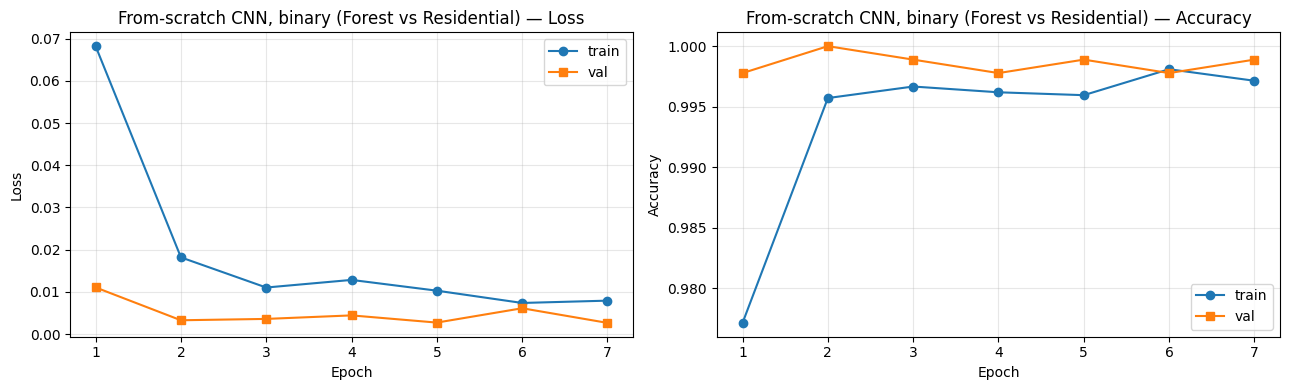

In [ ]:
# --- Plot training curves ---
def plot_history(history, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], 'o-', label='train')
    axes[0].plot(epochs, history['val_loss'],   's-', label='val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title_prefix} — Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], 'o-', label='train')
    axes[1].plot(epochs, history['val_acc'],   's-', label='val')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title_prefix} — Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_history(history_scratch_binary, 'From-scratch CNN, binary (Forest vs Residential)')


Test loss:     0.0032
Test accuracy: 1.0000

Classification report:
              precision    recall  f1-score   support

      Forest     1.0000    1.0000    1.0000       450
 Residential     1.0000    1.0000    1.0000       450

    accuracy                         1.0000       900
   macro avg     1.0000    1.0000    1.0000       900
weighted avg     1.0000    1.0000    1.0000       900

ROC AUC: 1.0000


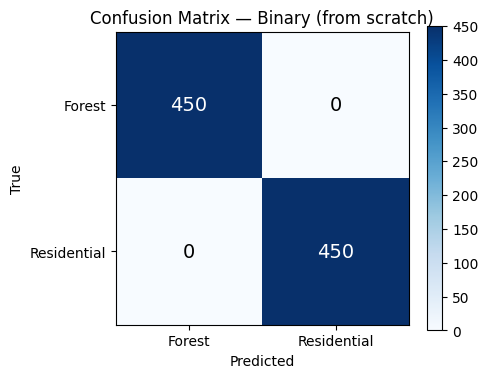

In [ ]:
# --- Evaluate on the test set ---
# This is the ONE time we look at test. Everything we've done so far only used
# train and val. Now we lock in the final numbers.

test_loss, test_acc, test_preds, test_targets, test_probs = evaluate(
    model_scratch_binary, bin_test_loader, criterion, DEVICE, is_binary=True
)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# --- Detailed metrics for binary classification ---
# Accuracy alone is often misleading. Always look at:
# - Precision, recall, F1 per class
# - Confusion matrix
# - ROC AUC (threshold-independent metric — very useful for binary)

print("\nClassification report:")
print(classification_report(test_targets, test_preds,
                            target_names=['Forest', 'Residential'], digits=4))

# ROC AUC uses the probabilities, not the hard predictions.
# AUC = probability that a random positive has a higher score than a random negative.
# AUC = 0.5 is random; 1.0 is perfect. This is threshold-independent, which is
# why it's often reported over raw accuracy.
auc = roc_auc_score(test_targets, test_probs)
print(f"ROC AUC: {auc:.4f}")

# Confusion matrix
cm = confusion_matrix(test_targets, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Forest', 'Residential'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Forest', 'Residential'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Binary (from scratch)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
plt.colorbar(im)
plt.tight_layout()
plt.show()


### What to notice

- Forest vs Residential is an easy task — our tiny from-scratch CNN likely hit **>98%** test accuracy.
- The **ROC AUC** is typically near 0.999 for easy binary problems. When AUC is that high, the classifier separates the classes well at *any* threshold.
- The **confusion matrix** should be nearly diagonal.

This is the "hello world" of deep learning image classification. Now let's scale up.


---
## Section 5: Multi-Class Classification From Scratch — All 10 Classes

**The model code is identical** except for two changes:

1. `num_outputs=10` instead of 1.
2. Loss function is `nn.CrossEntropyLoss()` instead of `nn.BCEWithLogitsLoss()`.

That's it. The convolutional feature extractor doesn't care how many classes there are.

### Why CrossEntropyLoss takes `long` labels

Subtle but important. For multi-class:

- **Logits** from the model: `[B, num_classes]` — raw scores.
- **Labels**: `[B]` — integer class IDs (0, 1, ..., num_classes-1).
- `nn.CrossEntropyLoss` internally does `LogSoftmax + NLLLoss`. The integer label is used to index into the class-probability distribution. Labels MUST be `long` (int64).

A common bug: passing float labels gives a cryptic error. Always `.long()` your labels for CE loss.


### Notes: Binary vs Multi-Class

The feature extractor does not need to change when moving from binary to multi-class classification. The key changes are the classifier output size, target dtype, and loss function.

**Binary setup used earlier**
- Output: `[B, 1]`
- Labels: float tensor `[B]`
- Loss: `BCEWithLogitsLoss`
- Prediction: `sigmoid(logit) > threshold`

**Multi-class setup used here**
- Output: `[B, 10]`
- Labels: long tensor `[B]`
- Loss: `CrossEntropyLoss`
- Prediction: `argmax(logits, dim=1)`


In [ ]:
# Multi-class dataset: use the full 10-class train/val/test splits from earlier.
# Label type must be 'long' for CrossEntropyLoss.

class MultiClassSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        # Returns the count of images in this specific split (train, val, or test)
        return len(self.indices)

    def __getitem__(self, idx):
        # 1. Map the subset index to the original EuroSAT folder structure
        path, label = self.dataset.samples[self.indices[idx]]

        # 2. Open image. We ensure RGB mode to avoid issues with grayscale satellite bands
        img = Image.open(path).convert('RGB')

        # 3. Apply the appropriate augmentation (train) or normalization (eval) pipeline
        if self.transform:
            img = self.transform(img)

        # 4. CRITICAL: CrossEntropyLoss in PyTorch expects labels as 'Long' integers (int64),
        # unlike BCE loss which expects 'Float' (float32).
        return img, torch.tensor(label, dtype=torch.long)

# --- Instantiate Multi-Class Dataset Splits ---
mc_train_ds = MultiClassSubset(full_dataset_raw, train_idx, train_tf_scratch)
mc_val_ds   = MultiClassSubset(full_dataset_raw, val_idx,   eval_tf_scratch)
mc_test_ds  = MultiClassSubset(full_dataset_raw, test_idx,  eval_tf_scratch)

# --- DataLoader Configuration ---
# - shuffle=True: ensures the model doesn't learn the specific order of the dataset
# - num_workers: enables parallel data loading using CPU sub-processes
# - pin_memory: speeds up data transfer to the GPU by using page-locked memory
mc_train_loader = DataLoader(mc_train_ds, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'))
mc_val_loader   = DataLoader(mc_val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'))
mc_test_loader  = DataLoader(mc_test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'))

print(f"Multi-class train: {len(mc_train_ds)}")
print(f"Multi-class val:   {len(mc_val_ds)}")
print(f"Multi-class test:  {len(mc_test_ds)}")

Multi-class train: 18900
Multi-class val:   4050
Multi-class test:  4050


In [ ]:
# --- Handle class imbalance with weighted loss ---
# We saw earlier that classes range from 2000 to 3000 samples. Not severe, but
# we can compensate by weighting each class inversely to its frequency.
#
# Industry rule of thumb: if max_count / min_count > 2, consider class weights.
# Ours is 3000/2000 = 1.5. Marginal. We'll use weights anyway to demonstrate
# the technique.

train_label_counts = np.array([0] * len(class_names))
for i in train_idx:
    _, lbl = full_dataset_raw.samples[i]
    train_label_counts[lbl] += 1

# Inverse-frequency weights, normalized so they average to 1
class_weights = train_label_counts.sum() / (len(class_names) * train_label_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Class weights (higher = upweight this class's loss contribution):")
for name, w, cnt in zip(class_names, class_weights.cpu().numpy(), train_label_counts):
    print(f"  {name:25s}  count={cnt:5d}  weight={w:.3f}")


Class weights (higher = upweight this class's loss contribution):
  AnnualCrop                 count= 2100  weight=0.900
  Forest                     count= 2100  weight=0.900
  HerbaceousVegetation       count= 2100  weight=0.900
  Highway                    count= 1750  weight=1.080
  Industrial                 count= 1750  weight=1.080
  Pasture                    count= 1400  weight=1.350
  PermanentCrop              count= 1750  weight=1.080
  Residential                count= 2100  weight=0.900
  River                      count= 1750  weight=1.080
  SeaLake                    count= 2100  weight=0.900


Epoch   1/25 | train_loss=0.9583 train_acc=0.6784 | val_loss=0.6762 val_acc=0.7677 | lr=1.00e-03 | 22.1s
Epoch   2/25 | train_loss=0.6587 train_acc=0.7784 | val_loss=0.5869 val_acc=0.7983 | lr=9.96e-04 | 34.1s
Epoch   3/25 | train_loss=0.5404 train_acc=0.8207 | val_loss=0.3969 val_acc=0.8677 | lr=9.84e-04 | 21.1s
Epoch   4/25 | train_loss=0.4620 train_acc=0.8447 | val_loss=0.3183 val_acc=0.8921 | lr=9.65e-04 | 22.3s
Epoch   5/25 | train_loss=0.4039 train_acc=0.8691 | val_loss=0.2794 val_acc=0.9091 | lr=9.38e-04 | 22.1s
Epoch   6/25 | train_loss=0.3532 train_acc=0.8822 | val_loss=0.2627 val_acc=0.9148 | lr=9.05e-04 | 21.2s
Epoch   7/25 | train_loss=0.3120 train_acc=0.8970 | val_loss=0.3400 val_acc=0.8812 | lr=8.64e-04 | 22.5s
Epoch   8/25 | train_loss=0.2906 train_acc=0.9015 | val_loss=0.2186 val_acc=0.9259 | lr=8.19e-04 | 22.8s
Epoch   9/25 | train_loss=0.2553 train_acc=0.9141 | val_loss=0.2697 val_acc=0.9035 | lr=7.68e-04 | 22.5s
Epoch  10/25 | train_loss=0.2424 train_acc=0.9197 | val

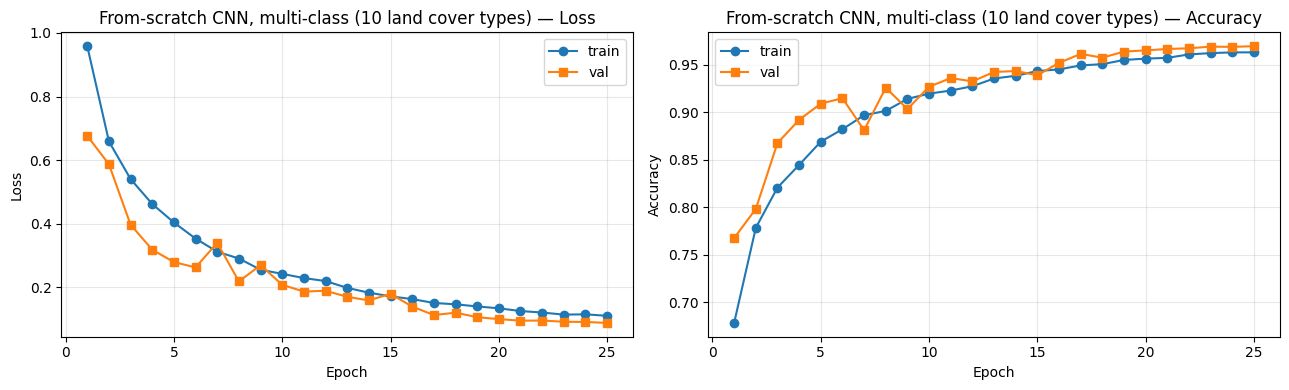

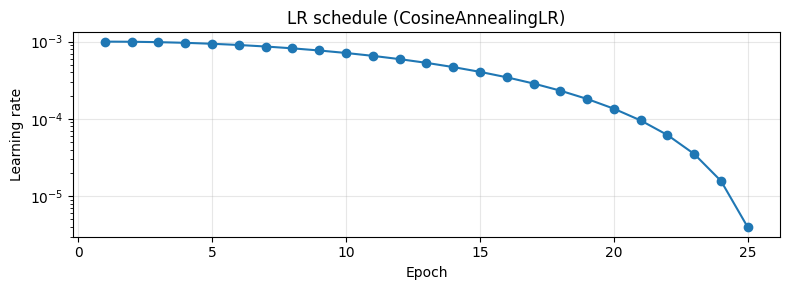

In [ ]:
# Model: same architecture, 10 outputs instead of 1
model_scratch_multi = SimpleCNN(num_outputs=10).to(DEVICE)

# Loss: CrossEntropyLoss with class weights
criterion_mc = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer: same Adam, same LR as before for multiclass
optimizer_mc = torch.optim.Adam(model_scratch_multi.parameters(), lr=1e-3)

# Scheduler: CosineAnnealingLR. Decays LR smoothly from initial to near-zero
# over `T_max` epochs. Popular industry default — tends to give slightly better
# final accuracy than constant LR. No hyperparameters to tune (beyond T_max).
EPOCHS_MC = 25 if DEVICE.type == 'cuda' else 10
scheduler_mc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_mc, T_max=EPOCHS_MC)

history_scratch_multi = fit(
    model=model_scratch_multi,
    train_loader=mc_train_loader,
    val_loader=mc_val_loader,
    optimizer=optimizer_mc,
    criterion=criterion_mc,
    epochs=EPOCHS_MC,
    device=DEVICE,
    is_binary=False,
    scheduler=scheduler_mc,
    early_stop_patience=7,
)

plot_history(history_scratch_multi, 'From-scratch CNN, multi-class (10 land cover types)')

# Also plot the learning rate schedule — useful to see what the scheduler did
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(1, len(history_scratch_multi['lr']) + 1), history_scratch_multi['lr'], 'o-')
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning rate'); ax.set_yscale('log')
ax.set_title('LR schedule (CosineAnnealingLR)'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


Test loss:     0.0705
Test accuracy: 0.9746

Classification report:
                      precision    recall  f1-score   support

          AnnualCrop      0.961     0.973     0.967       450
              Forest      0.993     0.996     0.994       450
HerbaceousVegetation      0.946     0.969     0.957       450
             Highway      0.976     0.989     0.983       375
          Industrial      0.974     0.992     0.983       375
             Pasture      0.963     0.967     0.965       300
       PermanentCrop      0.959     0.925     0.942       375
         Residential      0.998     0.978     0.988       450
               River      0.978     0.960     0.969       375
             SeaLake      0.993     0.989     0.991       450

            accuracy                          0.975      4050
           macro avg      0.974     0.974     0.974      4050
        weighted avg      0.975     0.975     0.975      4050



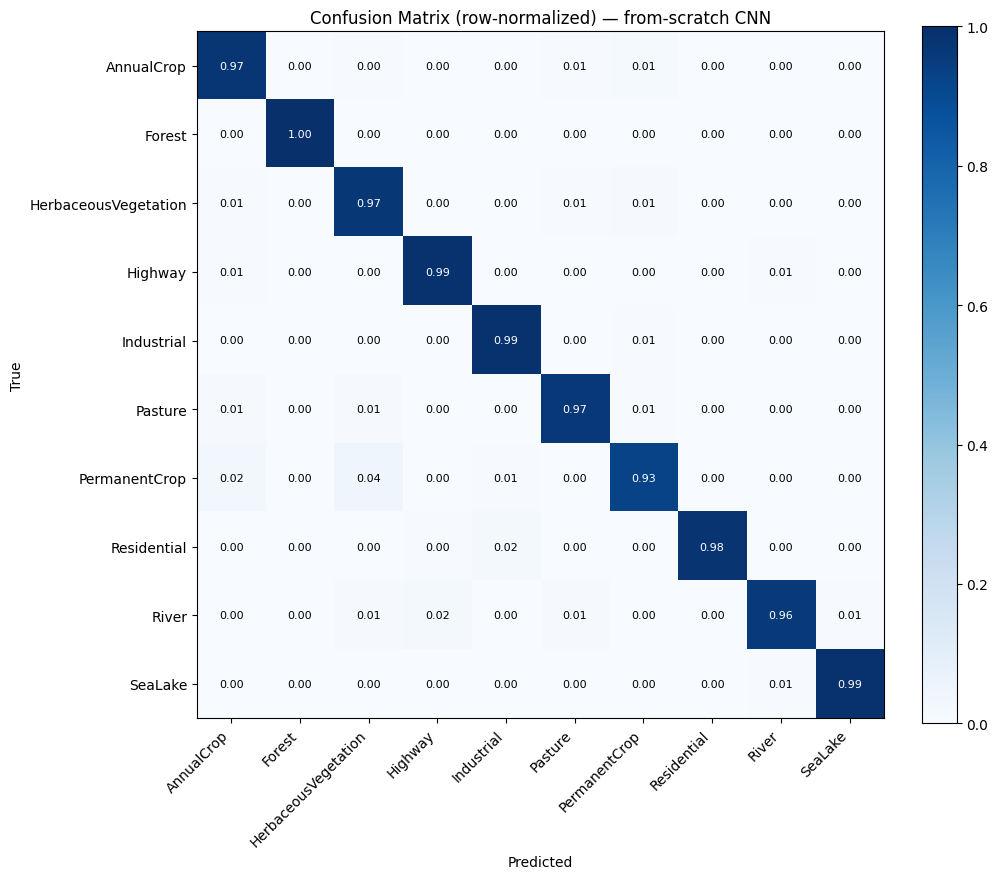

In [ ]:
# --- Evaluate on test ---
# Using distinct variable names so we can compare with transfer learning results later.
# We pass 'is_binary=False' to ensure the evaluate function uses softmax and argmax logic.
test_loss_scratch_mc, test_acc_scratch_mc, test_preds_sm, test_targets_sm, test_probs_sm = evaluate(
    model_scratch_multi, mc_test_loader, criterion_mc, DEVICE, is_binary=False
)
print(f"Test loss:     {test_loss_scratch_mc:.4f}")
print(f"Test accuracy: {test_acc_scratch_mc:.4f}")

# --- Per-class metrics ---
# The classification report provides Precision, Recall, and F1-score for each of the 10 classes.
# This is vital because overall accuracy can hide poor performance on minority classes.
print("\nClassification report:")
print(classification_report(test_targets_sm, test_preds_sm, target_names=class_names, digits=3))

# --- Confusion matrix visualization ---
# We create a confusion matrix to see specific error patterns (e.g., is River confused with SeaLake?).
cm = confusion_matrix(test_targets_sm, test_preds_sm)

# Normalize by the 'true' labels (rows). This shows the recall for each class on the diagonal
# and makes it easier to read the percentage of misclassifications in each row.
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)

# Set labels and ticks using the class names defined during dataset loading
ax.set_xticks(range(10)); ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticks(range(10)); ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix (row-normalized) — from-scratch CNN')

# Annotate the heatmap with the actual percentages
for i in range(10):
    for j in range(10):
        ax.text(j, i, f'{cm_norm[i, j]:.2f}', ha='center', va='center',
                color='white' if cm_norm[i, j] > 0.5 else 'black', fontsize=8)

plt.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()

### Reading the confusion matrix

The diagonal is correct predictions. Look at the off-diagonal hotspots — those are the class pairs the model confuses:

- **River ↔ SeaLake**: both are water. Visually similar. Classic hard pair.
- **AnnualCrop ↔ PermanentCrop ↔ HerbaceousVegetation ↔ Pasture**: four green-ish textures. Hard to separate without subtle texture cues.
- **Forest**: distinctive enough that almost no other class gets mistaken for it.
- **Residential, Industrial, Highway**: built-up areas. Some mutual confusion.

This is the pattern you'll find in almost every real classification task — a few easy classes, a few confused clusters. The confusion matrix tells you *where to spend your debugging time*.


---
## Section 6: Transfer Learning — Theory First

Now we shift to the approach you should use 95% of the time in industry: **start from a pretrained model, adapt it to your task**.

### Why transfer learning wins

A model pretrained on ImageNet (1.28 million images, 1000 classes) has already learned an enormous amount about visual features — edges, textures, shapes, object parts. Most of that knowledge transfers to whatever the task requires. You get a head start.

On small datasets (our 27K images is actually moderate, but it's still dwarfed by ImageNet's 1.28M), transfer learning typically:
- Reaches higher final accuracy
- Converges in far fewer epochs
- Needs much less hyperparameter tuning
- Is more robust to train/test distribution shift

### Two modes of transfer learning

```
┌─────────────────────────────────────────────────────────────────┐
│                                                                 │
│   MODE 1: Feature extraction (freeze the backbone)              │
│                                                                 │
│   Pretrained backbone   │   New classifier head                 │
│   ─────────────────────  │   ─────────────────────              │
│   FROZEN (no gradients)  │   TRAINABLE                          │
│                                                                 │
│   Fast, cheap, small dataset-friendly.                          │
│   Your starting point. Always try this first.                   │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│                                                                 │
│   MODE 2: Fine-tuning (selectively unfreeze)                    │
│                                                                 │
│   Early layers  │  Late layers  │  Head                         │
│   FROZEN        │  TRAINABLE    │  TRAINABLE                    │
│   (low LR)      │  (medium LR)  │  (high LR)                    │
│                                                                 │
│   Slower, more compute, more data-hungry. Usually gives +1–3%.  │
│   Use when Mode 1 isn't enough, or when your domain differs     │
│   significantly from ImageNet.                                  │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

### The "freeze the backbone, train the head" intuition

A pretrained ResNet-18 on ImageNet learns a hierarchy of features:
- **Early layers (conv1, layer1)**: edges, colors, simple textures. These are *universal*.
- **Middle layers (layer2, layer3)**: object parts (wheels, eyes, fur patterns). Somewhat general.
- **Late layers (layer4)**: object-level representations (dogs, cars, chairs). ImageNet-specific.
- **Final classifier**: "if the feature vector looks like this, it's probably a golden retriever."

For our satellite task, the early and middle layers are still useful — they detect textures and patterns regardless of what's in the image. The late layer and classifier are ImageNet-specific and need to be retrained.

### Industry-standard decision tree

```
Do I have a classification problem on natural images?
│
├── YES → Transfer learning with ImageNet pretrained weights.
│   │
│   ├── Dataset size < 1K images?         → Feature extraction only.
│   │                                       Low chance of fine-tuning helping.
│   │
│   ├── Dataset size 1K–10K?              → Feature extraction first.
│   │                                       Then try fine-tuning the last 1-2 blocks.
│   │
│   ├── Dataset size 10K–100K?            → Fine-tune the whole backbone with
│   │                                       discriminative LRs.
│   │
│   └── Dataset size > 100K?              → Full fine-tuning, may even benefit
│                                           from training parts from scratch.
│
└── NO (medical MRI, seismic, hyperspectral, etc.) →
    ImageNet weights may or may not help. Try both feature extraction and
    fully-random init. Use whichever validates better. Sometimes domain-specific
    pretraining (e.g. RadImageNet for medical) beats ImageNet.
```

Our EuroSAT case is moderate-sized (27K) *and* somewhat distant from ImageNet (satellite imagery is not natural photos), so we'll show both modes and let the results speak.

### Model choice: ResNet-18

- **ResNet-18** is the modern industry default starting point. It's small (11M params), fast, well-understood, and performs well.
- **ResNet-50** gives +1–2% accuracy typically, at ~3x training time. Good next choice.
- **EfficientNet, Vision Transformers** etc. exist but are more complex to tune. Start with ResNet.

Pretrained on ImageNet means **inputs must be 224×224 RGB, normalized with ImageNet mean/std**. We'll build new dataloaders accordingly.


### Notes: Transfer Learning Strategy

Transfer learning is the default starting point when the dataset is not extremely large. The pretrained model already contains general visual features, so the task becomes adapting the final classifier and optionally fine-tuning the later layers.

**Model alternatives**
- `resnet18`: fast baseline, good for limited compute.
- `resnet34` or `resnet50`: more capacity, more memory and time.
- `mobilenet_v3_small` / `efficientnet_b0`: efficient options for deployment.
- Vision Transformers: useful with larger datasets or strong pretrained weights, usually more demanding.


---
## Section 7: Transfer Learning Mode 1 — Feature Extraction (Backbone Frozen)

Steps:
1. Rebuild the data pipeline with 224×224 images (ResNet's expected input size).
2. Load ResNet-18 with ImageNet-pretrained weights.
3. **Freeze all the backbone weights** (`requires_grad = False`).
4. **Replace** the final `fc` layer with a new one matching our 10 classes.
5. Train — only the new `fc` weights will receive gradients.

### Why only train the head?

A frozen backbone means `backbone.parameters()` won't update. Gradients flow *through* the backbone during backprop (so we can update the head) but they don't modify backbone weights. This is:
- **Fast**: only ~5000 parameters to update (vs 11M).
- **Data-efficient**: low risk of overfitting the backbone to our small dataset.
- **Memory-efficient**: no optimizer state for frozen params.


### Notes: Freezing Parameters

`requires_grad=False` prevents a parameter from receiving gradient updates. The layer still participates in the forward pass.

**When to freeze**
- Small dataset
- Limited compute
- Need a fast baseline
- Pretrained features already match the task reasonably well

**When to unfreeze**
- Validation accuracy plateaus below target
- Dataset differs strongly from ImageNet
- Enough data and compute are available


In [ ]:
# --- New transforms for 224x224 input (ResNet's expected size) ---
# WHAT: We are upscaling images from 64x64 to 224x224 pixels.
# WHY: Pretrained models like ResNet-18 were trained on ImageNet images of size 224x224.
# While they can technically handle other sizes, using the original training size
# usually yields the best results during transfer learning.
IMG_SIZE_TL = 224

# WHAT: ImageNet specific mean and standard deviation.
# WHY: To use a pretrained backbone, your input data MUST be normalized using the
# exact same statistics the model saw during its original training on ImageNet.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf_tl = transforms.Compose([
    transforms.Resize((IMG_SIZE_TL, IMG_SIZE_TL)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    # Slightly stronger jitter for transfer learning as the model has more capacity
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_tf_tl = transforms.Compose([
    transforms.Resize((IMG_SIZE_TL, IMG_SIZE_TL)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# WHAT: Re-instantiating the dataset wrappers with the new 224x224 transforms.
mc_train_ds_tl = MultiClassSubset(full_dataset_raw, train_idx, train_tf_tl)
mc_val_ds_tl   = MultiClassSubset(full_dataset_raw, val_idx,   eval_tf_tl)
mc_test_ds_tl  = MultiClassSubset(full_dataset_raw, test_idx,  eval_tf_tl)

# WHAT: Reducing the batch size from 64 to 32.
# WHY: Upscaling to 224x224 increases the memory footprint per image by ~12x.
# We reduce the batch size to avoid 'Out of Memory' (OOM) errors on the GPU.
BATCH_SIZE_TL = 32 if DEVICE.type == 'cuda' else 8

mc_train_loader_tl = DataLoader(mc_train_ds_tl, batch_size=BATCH_SIZE_TL, shuffle=True,
                                num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'))
mc_val_loader_tl   = DataLoader(mc_val_ds_tl,   batch_size=BATCH_SIZE_TL, shuffle=False,
                                num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'))
mc_test_loader_tl  = DataLoader(mc_test_ds_tl,  batch_size=BATCH_SIZE_TL, shuffle=False,
                                num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'))

print(f"TL batch size: {BATCH_SIZE_TL}")
print(f"Train batches: {len(mc_train_loader_tl)}, Val batches: {len(mc_val_loader_tl)}")

TL batch size: 32
Train batches: 591, Val batches: 127


In [ ]:
# --- Load ResNet-18 with ImageNet weights ---
# ResNet18_Weights.DEFAULT points to the best-available set of ImageNet-trained
# weights. First call downloads ~45 MB from pytorch.org.

model_tl_fe = models.resnet18(weights=ResNet18_Weights.DEFAULT)
print("Original ResNet-18 architecture (head):")
print(f"  fc: {model_tl_fe.fc}")

# --- Step 1: Freeze the entire backbone ---
for param in model_tl_fe.parameters():
    param.requires_grad = False

# --- Step 2: Replace the fc head ---
# ResNet-18's fc is Linear(in_features=512, out_features=1000).
# We replace with Linear(512, 10) for EuroSAT. Newly-created layers have
# requires_grad=True by default, so only these weights will be trained.
num_ftrs = model_tl_fe.fc.in_features  # 512 for ResNet-18
model_tl_fe.fc = nn.Linear(num_ftrs, len(class_names))
model_tl_fe = model_tl_fe.to(DEVICE)

# --- Verify what's trainable ---
total = sum(p.numel() for p in model_tl_fe.parameters())
trainable = sum(p.numel() for p in model_tl_fe.parameters() if p.requires_grad)
print(f"\nTotal parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}  ({100 * trainable / total:.2f}% of total)")
print(f"Frozen parameters:    {total - trainable:,}")

# Sanity check: list layers with requires_grad=True to be certain
print("\nTrainable layers:")
for name, p in model_tl_fe.named_parameters():
    if p.requires_grad:
        print(f"  {name:30s}  {tuple(p.shape)}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


Original ResNet-18 architecture (head):
  fc: Linear(in_features=512, out_features=1000, bias=True)

Total parameters:     11,181,642
Trainable parameters: 5,130  (0.05% of total)
Frozen parameters:    11,176,512

Trainable layers:
  fc.weight                       (10, 512)
  fc.bias                         (10,)


Training feature-extraction model for 8 epochs...

Epoch   1/8 | train_loss=0.7463 train_acc=0.7848 | val_loss=0.5009 val_acc=0.8459 | lr=1.00e-03 | 86.8s
Epoch   2/8 | train_loss=0.4469 train_acc=0.8557 | val_loss=0.3776 val_acc=0.8751 | lr=9.62e-04 | 85.3s
Epoch   3/8 | train_loss=0.3919 train_acc=0.8726 | val_loss=0.3297 val_acc=0.8951 | lr=8.54e-04 | 85.8s
Epoch   4/8 | train_loss=0.3747 train_acc=0.8771 | val_loss=0.3300 val_acc=0.8879 | lr=6.91e-04 | 84.8s
Epoch   5/8 | train_loss=0.3532 train_acc=0.8854 | val_loss=0.3123 val_acc=0.8921 | lr=5.00e-04 | 86.1s
Epoch   6/8 | train_loss=0.3413 train_acc=0.8866 | val_loss=0.3019 val_acc=0.9002 | lr=3.09e-04 | 85.4s
Epoch   7/8 | train_loss=0.3420 train_acc=0.8900 | val_loss=0.3131 val_acc=0.8956 | lr=1.46e-04 | 85.0s
Epoch   8/8 | train_loss=0.3375 train_acc=0.8892 | val_loss=0.2899 val_acc=0.9035 | lr=3.81e-05 | 83.3s

Training complete in 682s. Best val_acc = 0.9035


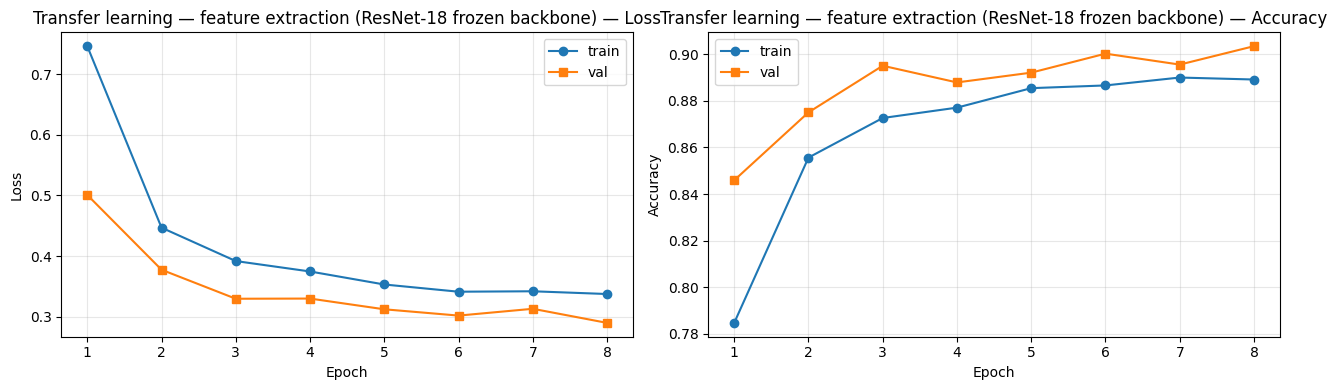

In [ ]:
# --- Training the feature extractor ---
# Critical detail: pass ONLY the trainable parameters to the optimizer.
# If you pass model.parameters() (all of them), optimizer state is allocated for
# frozen params too — wastes memory. Some optimizers (SGD with momentum, Adam)
# silently allocate state for frozen tensors.
#
# The clean pattern:
trainable_params = [p for p in model_tl_fe.parameters() if p.requires_grad]

# Learning rate:
# - Head was just randomly initialized → it can handle a 'normal' LR like 1e-3.
# - We're NOT updating the backbone, so there's no delicate-weight concern.
# - Adam with lr=1e-3 is a safe default.

criterion_tl = nn.CrossEntropyLoss(weight=class_weights)
optimizer_tl_fe = torch.optim.Adam(trainable_params, lr=1e-3)

# Scheduler: cosine annealing for a smooth LR decay.
EPOCHS_TL_FE = 8 if DEVICE.type == 'cuda' else 4
scheduler_tl_fe = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_tl_fe, T_max=EPOCHS_TL_FE)

print(f"Training feature-extraction model for {EPOCHS_TL_FE} epochs...\n")

history_tl_fe = fit(
    model=model_tl_fe,
    train_loader=mc_train_loader_tl,
    val_loader=mc_val_loader_tl,
    optimizer=optimizer_tl_fe,
    criterion=criterion_tl,
    epochs=EPOCHS_TL_FE,
    device=DEVICE,
    is_binary=False,
    scheduler=scheduler_tl_fe,
    early_stop_patience=4,
)

plot_history(history_tl_fe, 'Transfer learning — feature extraction (ResNet-18 frozen backbone)')


In [ ]:
# Evaluate
test_loss_fe, test_acc_fe, preds_fe, targets_fe, probs_fe = evaluate(
    model_tl_fe, mc_test_loader_tl, criterion_tl, DEVICE, is_binary=False
)
print(f"Feature extraction test accuracy: {test_acc_fe:.4f}")
print(classification_report(targets_fe, preds_fe, target_names=class_names, digits=3))


Feature extraction test accuracy: 0.9005
                      precision    recall  f1-score   support

          AnnualCrop      0.937     0.889     0.912       450
              Forest      0.944     0.971     0.957       450
HerbaceousVegetation      0.909     0.818     0.861       450
             Highway      0.816     0.875     0.844       375
          Industrial      0.910     0.995     0.950       375
             Pasture      0.834     0.890     0.861       300
       PermanentCrop      0.808     0.853     0.830       375
         Residential      0.966     0.940     0.953       450
               River      0.850     0.829     0.839       375
             SeaLake      0.993     0.933     0.962       450

            accuracy                          0.900      4050
           macro avg      0.897     0.899     0.897      4050
        weighted avg      0.903     0.900     0.901      4050



### What Expected result

Feature extraction typically reaches **~94-96%** test accuracy on EuroSAT in just a handful of epochs. That's likely already better than our from-scratch CNN, despite:
- Training 99%+ fewer parameters
- Running for way fewer epochs

This is the power of transfer learning. The pretrained backbone already knows how to extract useful features from images; we just taught it which features map to which of our 10 land-cover classes.

For limited compute or fast baselines, feature extraction is often a sufficient final solution. Feature extraction is a perfectly valid final solution for most problems.


---
## Section 8: Transfer Learning Mode 2 — Fine-Tuning with Discriminative Learning Rates

Now let's squeeze out the last few percentage points. We'll **unfreeze** parts of the backbone and continue training, but with a critical twist: **different learning rates for different parts of the network**. This is called **discriminative LRs** (or sometimes "layer-wise LR decay") and it's standard in production fine-tuning.

### Why different LRs for different layers?

Consider what we're doing:
- The **head** is fresh from feature extraction — it's already well-calibrated for our data. It needs the smallest adjustment.
- The **late backbone layers** (layer4 in ResNet) contain ImageNet-specific high-level features. These should be adjusted, but gently — they're already mostly good.
- The **early backbone layers** (conv1, layer1, layer2) contain generic low-level features. These should barely move at all — the "edge detector" in conv1 works for all images.

If we use a single LR:
- Too low → late layers don't adapt, we don't gain much over feature extraction.
- Too high → we catastrophically forget the useful pretrained features in the early layers.

The fix: **10x smaller LR as you go deeper into the backbone** toward the input.

### Typical industry pattern

```
Layer group          │  LR (relative to head LR)
──────────────────────┼─────────────────────────
Head (new fc)         │  1x       (e.g., 1e-3)
Late backbone (layer4)│  0.1x     (e.g., 1e-4)
Mid backbone  (layer3)│  0.03x    (e.g., 3e-5)
Early (conv1, layer1) │  0.01x    (e.g., 1e-5) — or keep frozen
```

The head's LR is already smaller than from-scratch because the weights we're adjusting are close to good. A typical fine-tuning head LR is 1e-3 or 1e-4.

### Warm-up strategy

Before we unfreeze and go wild, we do a **two-phase training**:

**Phase A — Warm up the head (feature extraction).** Backbone frozen, train just the head for a few epochs. This gets the head to a reasonable starting point. (We already did this in Section 7 — we'll reuse those weights!)

**Phase B — Unfreeze and fine-tune.** Unfreeze the backbone, apply discriminative LRs, continue training.

Skipping warm-up is a common beginner mistake. If you unfreeze everything on day 1 with a randomly-initialized head, the head's gradients are enormous (it's predicting noise), those gradients propagate into the backbone, and you destroy the pretrained features.


### Notes: Fine-Tuning Parameters

Fine-tuning updates pretrained weights, so learning rates must be smaller than from-scratch training.

**Parameter alternatives**
- `HEAD_LR = 1e-3`: can be reduced to `1e-4` if validation loss is unstable.
- `LATE_LR = 1e-4`: often a good starting point for the last ResNet block.
- `EARLY_LR = 1e-5`: can be set to `0` by keeping early layers frozen.
- `weight_decay=1e-4`: increase slightly if overfitting, reduce if underfitting.
- `max_norm=1.0`: gradient clipping threshold; useful when fine-tuning is unstable.


In [ ]:
# --- Start from the feature extraction checkpoint ---
# The weights in model_tl_fe are already optimized for our head — that's the
# warm-up. Now unfreeze the backbone.

model_tl_ft = copy.deepcopy(model_tl_fe)  # start from warmed-up feature-extraction model

# --- Unfreeze everything ---
for param in model_tl_ft.parameters():
    param.requires_grad = True

# --- Set up discriminative LR parameter groups ---
# ResNet-18 structure (check with print(model_tl_ft)):
#   conv1, bn1, relu, maxpool  → 'stem'
#   layer1                     → early
#   layer2                     → mid-early
#   layer3                     → mid-late
#   layer4                     → late
#   avgpool, fc                → head

HEAD_LR = 1e-3     # LR for the new fc layer
LATE_LR = 1e-4     # LR for layer4
MID_LR  = 3e-5     # LR for layer3
EARLY_LR = 1e-5    # LR for layer1, layer2, stem

# We build parameter groups as a list of dicts: each dict has 'params' and 'lr' keys.
# PyTorch's optimizer supports this natively — different LRs per group.
param_groups = [
    # Head (newly trained). Highest LR.
    {'params': model_tl_ft.fc.parameters(),     'lr': HEAD_LR,  'name': 'head'},

    # Late backbone — layer4 contains ImageNet-object-level features.
    {'params': model_tl_ft.layer4.parameters(), 'lr': LATE_LR,  'name': 'layer4'},

    # Mid backbone
    {'params': model_tl_ft.layer3.parameters(), 'lr': MID_LR,   'name': 'layer3'},

    # Early backbone. Lowest LR because these features (edges, textures) generalize.
    {'params': model_tl_ft.layer2.parameters(), 'lr': EARLY_LR, 'name': 'layer2'},
    {'params': model_tl_ft.layer1.parameters(), 'lr': EARLY_LR, 'name': 'layer1'},
    {'params': model_tl_ft.conv1.parameters(),  'lr': EARLY_LR, 'name': 'conv1'},
    {'params': model_tl_ft.bn1.parameters(),    'lr': EARLY_LR, 'name': 'bn1'},
]

# Print group sizes so the output shows what's being trained with what LR
print("Discriminative LR parameter groups:")
for g in param_groups:
    n_params = sum(p.numel() for p in g['params'])
    print(f"  {g['name']:10s}  lr={g['lr']:.0e}  params={n_params:>10,}")

# Use AdamW (Adam + decoupled weight decay — prefered modern variant).
# weight_decay=1e-4 is a mild L2 regularizer, standard for image models.
optimizer_tl_ft = torch.optim.AdamW(param_groups, weight_decay=1e-4)

EPOCHS_TL_FT = 6 if DEVICE.type == 'cuda' else 3

# One-cycle LR scheduler: LR goes up then down across the epochs. Often performs
# better than cosine annealing for fine-tuning. We pass max_lr as a list matching
# our param groups.
max_lrs = [g['lr'] for g in param_groups]
scheduler_tl_ft = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_tl_ft,
    max_lr=max_lrs,
    epochs=EPOCHS_TL_FT,
    steps_per_epoch=len(mc_train_loader_tl),
    pct_start=0.1,           # 10% of total steps spent warming up the LR
    anneal_strategy='cos',
)

# OneCycleLR steps once per BATCH (not per epoch), so we need a modified fit loop
# or we handle it manually. For teaching clarity we'll do it manually below.


Discriminative LR parameter groups:
  head        lr=1e-03  params=     5,130
  layer4      lr=1e-04  params= 8,393,728
  layer3      lr=3e-05  params= 2,099,712
  layer2      lr=1e-05  params=   525,568
  layer1      lr=1e-05  params=   147,968
  conv1       lr=1e-05  params=     9,408
  bn1         lr=1e-05  params=       128



Fine-tuning for 6 epochs with discriminative LRs...

Epoch  1/6 | train_loss=0.3348 train_acc=0.8927 | val_loss=0.3051 val_acc=0.8975 | 94.0s
Epoch  2/6 | train_loss=0.3336 train_acc=0.8922 | val_loss=0.2995 val_acc=0.8973 | 93.8s
Epoch  3/6 | train_loss=0.3299 train_acc=0.8943 | val_loss=0.2916 val_acc=0.9015 | 96.1s
Epoch  4/6 | train_loss=0.3259 train_acc=0.8947 | val_loss=0.3029 val_acc=0.8978 | 95.7s
Epoch  5/6 | train_loss=0.3294 train_acc=0.8920 | val_loss=0.2903 val_acc=0.9020 | 94.8s
Epoch  6/6 | train_loss=0.3297 train_acc=0.8904 | val_loss=0.2823 val_acc=0.9064 | 95.4s

Best val accuracy achieved: 0.9064


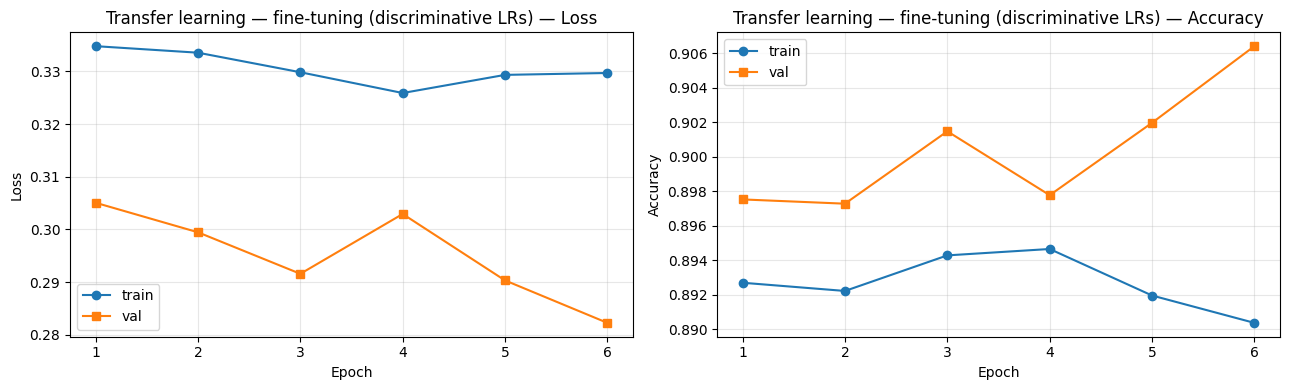

In [ ]:
# --- Fine-tuning Loop with Line-by-Line Documentation ---

# Log the start of the fine-tuning process
print(f"\nFine-tuning for {EPOCHS_TL_FT} epochs with discriminative LRs...\n")

# Initialize dictionary to store metrics for plotting later
history_tl_ft = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# Track the highest validation accuracy found so far
best_val_acc = 0

# Store the initial state of the model as the 'best' state temporarily
best_state = copy.deepcopy(model_tl_ft.state_dict())

# Counter for early stopping if the model stops improving
patience = 0

# Main training loop iterating over the defined number of epochs
for epoch in range(1, EPOCHS_TL_FT + 1):
    # Capture start time to measure epoch duration
    t0 = time.time()

    # Set model to training mode (enables Dropout and BatchNormalization training behavior)
    model_tl_ft.train()

    # Reset running totals for loss and accuracy at the start of the epoch
    tr_loss_sum, tr_correct, tr_total = 0, 0, 0

    # Iterate through the training DataLoader batch by batch
    for inputs, targets in mc_train_loader_tl:
        # Move images to GPU (if available) without blocking CPU execution
        inputs = inputs.to(DEVICE, non_blocking=True)
        # Move integer labels to GPU
        targets = targets.to(DEVICE, non_blocking=True)

        # Clear the gradients from the previous batch to prevent accumulation
        optimizer_tl_ft.zero_grad()

        # Forward pass: compute predicted logits by passing inputs through the network
        outputs = model_tl_ft(inputs)

        # Calculate the error between predictions and ground truth using weighted CrossEntropy
        loss = criterion_tl(outputs, targets)

        # Backward pass: compute the gradient of the loss with respect to all model parameters
        loss.backward()

        # Scale gradients down if their norm exceeds 1.0 to prevent training instability
        torch.nn.utils.clip_grad_norm_(model_tl_ft.parameters(), max_norm=1.0)

        # Update weights using the AdamW optimizer based on the calculated gradients
        optimizer_tl_ft.step()

        # Step the OneCycleLR scheduler after every batch to adjust learning rates per the cycle
        scheduler_tl_ft.step()

        # Accumulate the total loss (multiplied by batch size to get weighted average later)
        tr_loss_sum += loss.item() * inputs.size(0)
        # Count how many images in this batch were correctly classified
        tr_correct += (outputs.argmax(1) == targets).sum().item()
        # Track the total number of images processed in this epoch
        tr_total += inputs.size(0)

    # --- Validation Phase ---
    # Evaluate current model performance on the held-out validation set
    val_loss, val_acc, _, _, _ = evaluate(model_tl_ft, mc_val_loader_tl, criterion_tl, DEVICE, is_binary=False)

    # Calculate average training loss for the epoch
    tr_loss = tr_loss_sum / tr_total
    # Calculate overall training accuracy for the epoch
    tr_acc = tr_correct / tr_total

    # Append epoch metrics to the history dictionary
    history_tl_ft['train_loss'].append(tr_loss)
    history_tl_ft['train_acc'].append(tr_acc)
    history_tl_ft['val_loss'].append(val_loss)
    history_tl_ft['val_acc'].append(val_acc)

    # Calculate time taken for the current epoch
    dt = time.time() - t0

    # Print status update for the current epoch
    print(f"Epoch {epoch:2d}/{EPOCHS_TL_FT} | "
          f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | {dt:.1f}s")

    # --- Best Model Tracking ---
    # If current validation accuracy is the best seen so far, save weights
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model_tl_ft.state_dict())
        patience = 0
    else:
        # If no improvement, increment patience counter
        patience += 1
        # Exit loop if model has not improved for 3 consecutive epochs
        if patience >= 3:
            print("Early stop triggered: No improvement in validation accuracy.")
            break

# After training, reload the best performing weights into the model
model_tl_ft.load_state_dict(best_state)
print(f"\nBest val accuracy achieved: {best_val_acc:.4f}")

# Generate plots for training vs. validation loss and accuracy
plot_history(history_tl_ft, 'Transfer learning — fine-tuning (discriminative LRs)')

Fine-tuning test accuracy: 0.9049
                      precision    recall  f1-score   support

          AnnualCrop      0.954     0.878     0.914       450
              Forest      0.938     0.973     0.955       450
HerbaceousVegetation      0.913     0.838     0.874       450
             Highway      0.838     0.853     0.845       375
          Industrial      0.903     0.992     0.945       375
             Pasture      0.870     0.890     0.880       300
       PermanentCrop      0.817     0.869     0.842       375
         Residential      0.964     0.942     0.953       450
               River      0.832     0.848     0.840       375
             SeaLake      0.986     0.951     0.968       450

            accuracy                          0.905      4050
           macro avg      0.901     0.903     0.902      4050
        weighted avg      0.907     0.905     0.905      4050



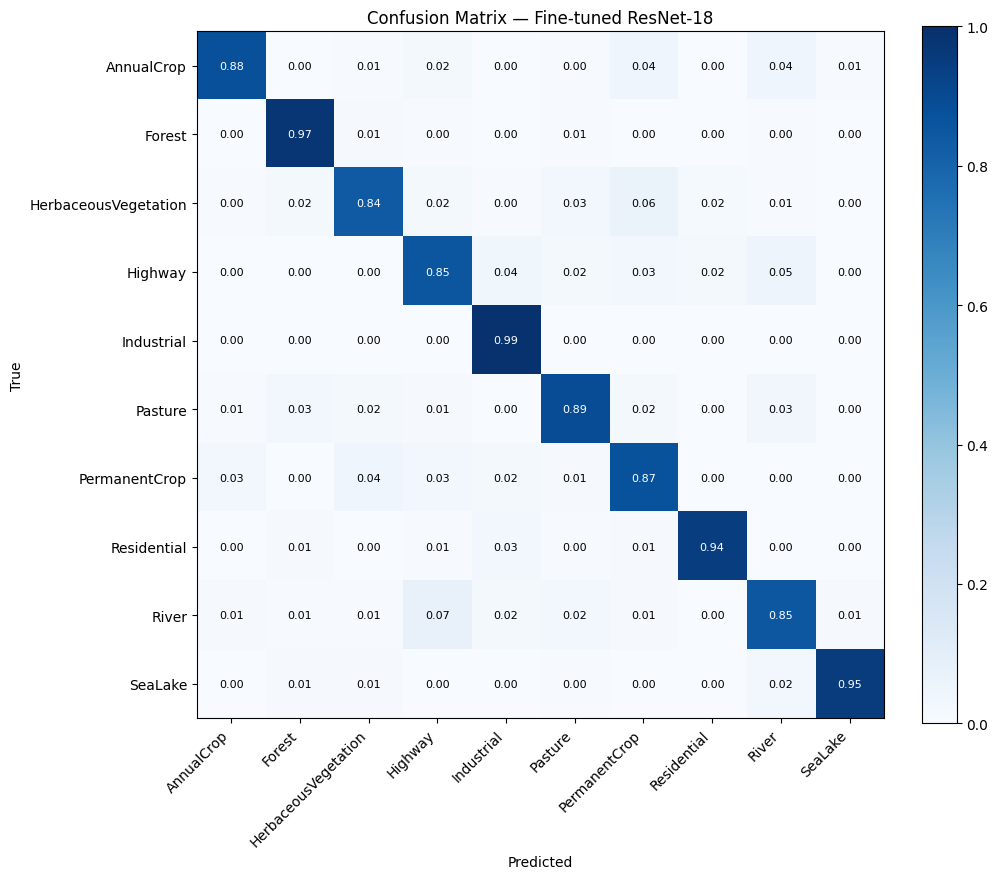

In [ ]:
# Final test evaluation
test_loss_ft, test_acc_ft, preds_ft, targets_ft, probs_ft = evaluate(
    model_tl_ft, mc_test_loader_tl, criterion_tl, DEVICE, is_binary=False
)
print(f"Fine-tuning test accuracy: {test_acc_ft:.4f}")
print(classification_report(targets_ft, preds_ft, target_names=class_names, digits=3))

# Confusion matrix
cm = confusion_matrix(targets_ft, preds_ft)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(10)); ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticks(range(10)); ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Fine-tuned ResNet-18')
for i in range(10):
    for j in range(10):
        ax.text(j, i, f'{cm_norm[i, j]:.2f}', ha='center', va='center',
                color='white' if cm_norm[i, j] > 0.5 else 'black', fontsize=8)
plt.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()


---
## Section 9: Putting the Three Models Side-by-Side

Let's compare everything we built.


In [ ]:
# Compile a summary table
summary_df = pd.DataFrame([
    {
        'model':             'From-scratch CNN (multi-class)',
        'params':            sum(p.numel() for p in model_scratch_multi.parameters()),
        'epochs':            len(history_scratch_multi['train_loss']),
        'test_accuracy':     test_acc_scratch_mc,
    },
    {
        'model':             'TL: Feature extraction (ResNet-18 frozen)',
        'params':            sum(p.numel() for p in model_tl_fe.parameters()),
        'epochs':            len(history_tl_fe['train_loss']),
        'test_accuracy':     test_acc_fe,
    },
    {
        'model':             'TL: Fine-tuned (discriminative LRs)',
        'params':            sum(p.numel() for p in model_tl_ft.parameters()),
        'epochs':            len(history_tl_ft['train_loss']) + len(history_tl_fe['train_loss']),
        'test_accuracy':     test_acc_ft,
    },
])
summary_df['params'] = summary_df['params'].apply(lambda x: f'{x:,}')
summary_df['test_accuracy'] = summary_df['test_accuracy'].apply(lambda x: f'{x:.4f}')
print(summary_df.to_string(index=False))


                                    model     params  epochs test_accuracy
           From-scratch CNN (multi-class)    289,194      25        0.9746
TL: Feature extraction (ResNet-18 frozen) 11,181,642       8        0.9005
      TL: Fine-tuned (discriminative LRs) 11,181,642      14        0.9049


### Expected ordering of results

In almost every run:
```
Fine-tuned  >  Feature extraction  >  From-scratch
```

Typical numbers on EuroSAT:
- From scratch: ~85-90%
- Feature extraction: ~94-96%
- Fine-tuned: ~97-98%

The gap between from-scratch and transfer learning is *huge*. The gap between feature extraction and fine-tuning is smaller but still meaningful. This ordering is extremely consistent across problems — this is why pretrained models are the default starting point for new classification tasks in industry.


---
## Section 10: Industry Cheat Sheet — What to Do When

A condensed reference. Use this as a compact reference.

### Architecture choice
| Dataset size | Architecture |
|---|---|
| <1K images | Feature extraction with ResNet-18 or MobileNet. Do not train from scratch. |
| 1K–10K | Feature extraction + fine-tune last 1 block of ResNet-18 or -34. |
| 10K–100K | Full fine-tune of ResNet-18/-50 with discriminative LRs. Try EfficientNet-B0/-B3. |
| >100K | Consider ResNet-50+, EfficientNet-B3+, or ViT variants. Full fine-tune. |

### Learning rate starting points
| Scenario | LR |
|---|---|
| From scratch, Adam | 1e-3 |
| From scratch, SGD+momentum | 1e-2 (with warmup and cosine decay) |
| TL head only (feature extraction) | 1e-3 |
| TL fine-tuning head | 1e-3 or 1e-4 |
| TL fine-tuning late backbone | 1e-4 |
| TL fine-tuning mid backbone | 3e-5 |
| TL fine-tuning early backbone | 1e-5 (or freeze) |

### Batch size
- Start at 32–64. Go as high as memory allows — larger batches = better GPU utilization.
- But: larger batch → less gradient noise → usually needs larger LR. Rule of thumb: LR scales with sqrt(batch_size).
- Very large batches (>256) need careful warmup or they destabilize early training.

### Weight decay
- `0` or `1e-5` for small data / small models (low risk of overfitting).
- `1e-4` standard default for modern image models with AdamW.
- `5e-4` for larger models or when validation shows overfitting.

### Augmentation strength
- Weak (flips only): <1K images, risk of losing signal.
- Medium (flips + crops + mild color jitter): 1K–100K. Our setting.
- Strong (AugMix, RandAugment, CutMix, MixUp): 100K+ images.

### When to unfreeze what (fine-tuning schedule)
```
Epoch 0-N:   Head only (feature extraction warmup)
Epoch N+:    Unfreeze layer4 (LR=1e-4)
Epoch 2N+:   Unfreeze layer3 (LR=3e-5)
Epoch 3N+:   Unfreeze layer2, layer1 (LR=1e-5, or keep frozen)
```
Typical N = 3-5 epochs. Newer practice: unfreeze everything at once with discriminative LRs (what we did above). Both work; progressive unfreeze is more conservative.

### Things to always do
- **Stratified splits** (not random).
- **Look at the data before training**.
- **Per-class metrics**, not just overall accuracy.
- **Confusion matrix** to find class-pair failure modes.
- **Save best-val checkpoint**, not the final one.
- **Model in `.eval()` mode** during evaluation (never forget — BatchNorm will silently produce wrong results).
- **`with torch.no_grad()`** during evaluation (saves memory, makes it faster).
- **Set all seeds**, accept that perfect reproducibility isn't free on GPU.
- **Log learning rate** every epoch (at minimum).

### Things to never do
- Never tune hyperparameters on the test set.
- Never use validation augmentation (the val metric is meaningless with randomness).
- Never train from scratch when a pretrained backbone exists in your domain.
- Never deploy the `last` checkpoint — always deploy `best` (by val metric).
- Never forget to switch BatchNorm to eval mode when evaluating.


### Notes: How to Use the Cheat Sheet

Treat the values as starting points, not fixed rules. A reliable workflow is to start with the simplest transfer-learning baseline, inspect validation curves, then adjust one variable at a time: learning rate, augmentation strength, batch size, or unfreezing depth.


---
## Section 11: Production Readiness Checklist

Before deploying any classification model:

**Data side**
- [ ] Stratified train/val/test split with preserved class proportions
- [ ] Test set locked away, only evaluated on at the end
- [ ] Class distribution documented
- [ ] Data-sheet written: where did it come from, how was it labelled, known biases
- [ ] Visualized random samples from every class

**Model side**
- [ ] Pretrained backbone used (if applicable)
- [ ] Correct loss function (BCE for binary, CE for multi-class, focal for severe imbalance)
- [ ] BatchNorm and Dropout in correct train/eval modes during corresponding phases
- [ ] Model saved with `state_dict` (not the model object — non-portable)

**Training side**
- [ ] Seeds set, runs logged
- [ ] Best-val checkpoint saved
- [ ] Early stopping configured
- [ ] LR schedule reasonable, LR logged per epoch
- [ ] Gradient clipping if using large LRs or RNNs

**Evaluation side**
- [ ] Per-class precision/recall/F1 reported
- [ ] Confusion matrix visualized
- [ ] Calibration checked (are predicted probabilities actually well-calibrated?)
- [ ] Error analysis on worst-case samples
- [ ] Robustness tested on slightly-out-of-distribution data

**Deployment side**
- [ ] Model exported to target format (ONNX, TorchScript, TFLite)
- [ ] Pre/postprocessing locked in (same transforms as training eval)
- [ ] Latency benchmarked on target hardware
- [ ] Monitoring in place for prediction distribution drift


---
## Section 12: Practice Extensions

Use these extensions to validate the concepts and compare modeling choices.

**1. Freeze/unfreeze ablation.**
Train three ResNet-18 variants:
   - (a) Everything frozen except `fc`.
   - (b) Everything frozen except `fc` and `layer4`.
   - (c) Everything trainable (full fine-tune, single LR).
Compare test accuracy and training time. Which wins?

**2. Learning rate finder.**
Implement a simple LR range test: start at LR=1e-7, increase exponentially every batch, plot loss vs LR. The optimal LR is usually around the steepest descent point. Use it to pick a new LR for the fine-tuning run and compare.

**3. Class weights vs. sampling.**
Instead of `CrossEntropyLoss(weight=...)`, try a `WeightedRandomSampler` in the DataLoader that oversamples minority classes. Which approach gives better per-class F1?

**4. Harder binary pair.**
Repeat the binary classification with Forest vs Residential replaced by:
   - River vs SeaLake (visually similar)
   - AnnualCrop vs PermanentCrop (both crops)
Does the from-scratch CNN still hit >98%? If not, how much transfer learning helps?

**5. Scale the model up.**
Replace ResNet-18 with ResNet-50. How much does test accuracy improve? How much does training time increase? Is it worth it?

**6. Test-time augmentation (TTA).**
Implement TTA: for each test image, create multiple augmented versions (flips, rotations), run inference on all, average the probabilities. Does this improve test accuracy? By how much?

